# Load Data

## Env

In [1]:
from pathlib import Path
import sys
import logging

project_root = str(Path("/home/user/perso/trading/alphalab").resolve())

if project_root not in sys.path:
    sys.path.append(project_root)

# Configuration de l'autocomplétion Jupyter
%config IPCompleter.use_jedi = False
%config IPCompleter.greedy = False

# Activation de l'autoreload
%load_ext autoreload
%autoreload 2

logging.basicConfig(
    level=logging.INFO,
    format='[%(levelname)s] %(message)s',
    stream=sys.stdout,
    force=False,
)

logging.getLogger('enl').setLevel(logging.INFO)

## Time Bars

In [24]:
import numpy as np
from enl.data_feed import *

start = '2021-01-01'
end = '2021-03-31'
# df = load_pair_time_bars('GBPUSD', 'EURUSD', start, end, '30min', ['close'], use_optim=True, use_thread=True)
df = load_pair_time_bars('EURUSD', 'GBPUSD', start, end, '30min', ['close'], use_optim=True, use_thread=True)
# df = load_pair_time_bars('GBPUSD', 'USDCHF', start, end, '30min', ['close'], use_optim=True, use_thread=True)
df = df[['timestamp', 'x_close', 'y_close']]

# Compute log_return
df['x_return'] = np.log(df['x_close']) - np.log(df['x_close'].shift(1))
df['y_return'] = np.log(df['y_close']) - np.log(df['y_close'].shift(1))
df = df.dropna().reset_index(drop=True)

df

[WARNING] File "/home/user/perso/trading/alphalab/data/GBPUSD/raw/GBPUSD_TICKS_2021_01_01.parquet" not found
[WARNING] File "/home/user/perso/trading/alphalab/data/EURUSD/raw/EURUSD_TICKS_2021_01_01.parquet" not found


[WARNING] 1156 bars have been dropped
[WARNING] 1156 bars have been dropped
[INFO] Pair "EURUSD (X) / GBPUSD (Y)" loaded (2976 bars)


,timestamp,x_close,y_close,x_return,y_return
0,2021-01-03 22:30:00,1.223435,1.366125,-0.000266,0.000282
1,2021-01-03 23:00:00,1.224015,1.366920,0.000474,0.000582
2,2021-01-03 23:30:00,1.225015,1.368095,0.000817,0.000859
3,2021-01-04 00:00:00,1.224565,1.366650,-0.000367,-0.001057
4,2021-01-04 00:30:00,1.224080,1.367325,-0.000396,0.000494
...,...,...,...,...,...
2970,2021-03-30 21:30:00,1.171815,1.373860,-0.000021,-0.000018
2971,2021-03-30 22:00:00,1.171840,1.374250,0.000021,0.000284
2972,2021-03-30 22:30:00,1.171790,1.374025,-0.000043,-0.000164
2973,2021-03-30 23:00:00,1.172180,1.374270,0.000333,0.000178


# Price Dispersion

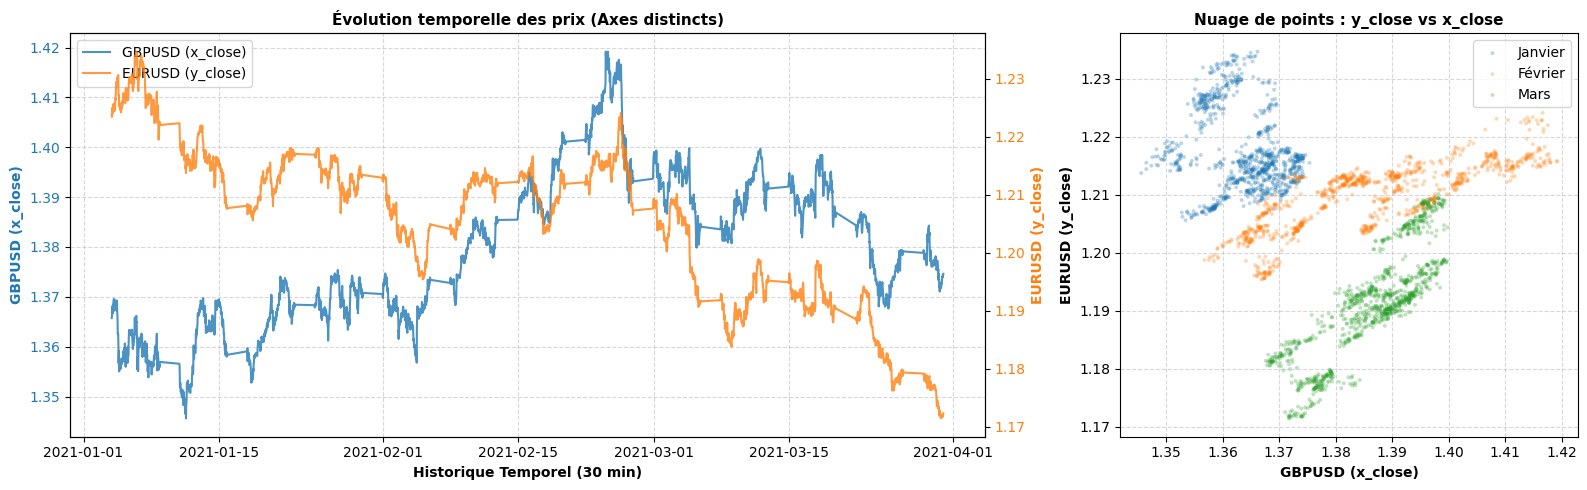

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Sécurité : Conversion de la colonne timestamp en type Datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Séparation des données par mois pour le scatter plot
janvier = df[df['timestamp'].dt.month == 1]
fevrier = df[df['timestamp'].dt.month == 2]
mars = df[df['timestamp'].dt.month == 3]

# 3. Configuration de la figure sur une seule ligne (Ratios d'affichage : 2/3 et 1/3)
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 1]})

# ---------------------------------------------------------------------
# PANNEAU DE GAUCHE : Évolution temporelle des prix (Double Axe Y)
# ---------------------------------------------------------------------
color_x = '#1f77b4'  # Bleu
ax1.set_xlabel('Historique Temporel (30 min)', fontweight='bold')
ax1.set_ylabel('GBPUSD (x_close)', color=color_x, fontweight='bold')
line1 = ax1.plot(df['timestamp'], df['x_close'], color=color_x, label='GBPUSD (x_close)', alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color_x)
ax1.grid(True, linestyle='--', alpha=0.5)

# Axe secondaire pour EURUSD
ax2 = ax1.twinx()
color_y = '#ff7f0e'  # Orange
ax2.set_ylabel('EURUSD (y_close)', color=color_y, fontweight='bold')
line2 = ax2.plot(df['timestamp'], df['y_close'], color=color_y, label='EURUSD (y_close)', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color_y)

# Regroupement des légendes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')
ax1.set_title("Évolution temporelle des prix (Axes distincts)", fontsize=11, fontweight='bold')

# ---------------------------------------------------------------------
# PANNEAU DE DROITE : Le Nuage de points (Coloration par mois)
# ---------------------------------------------------------------------
# On trace chaque mois séparément avec sa propre couleur
ax3.scatter(janvier['x_close'], janvier['y_close'], color='#1f77b4', alpha=0.3, edgecolors='none', s=8, label="Janvier")
ax3.scatter(fevrier['x_close'], fevrier['y_close'], color='#ff7f0e', alpha=0.3, edgecolors='none', s=8, label="Février")
ax3.scatter(mars['x_close'], mars['y_close'], color='#2ca02c', alpha=0.3, edgecolors='none', s=8, label="Mars")

ax3.set_xlabel('GBPUSD (x_close)', fontweight='bold')
ax3.set_ylabel('EURUSD (y_close)', fontweight='bold')
ax3.set_title("Nuage de points : y_close vs x_close", fontsize=11, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Using Logreturn

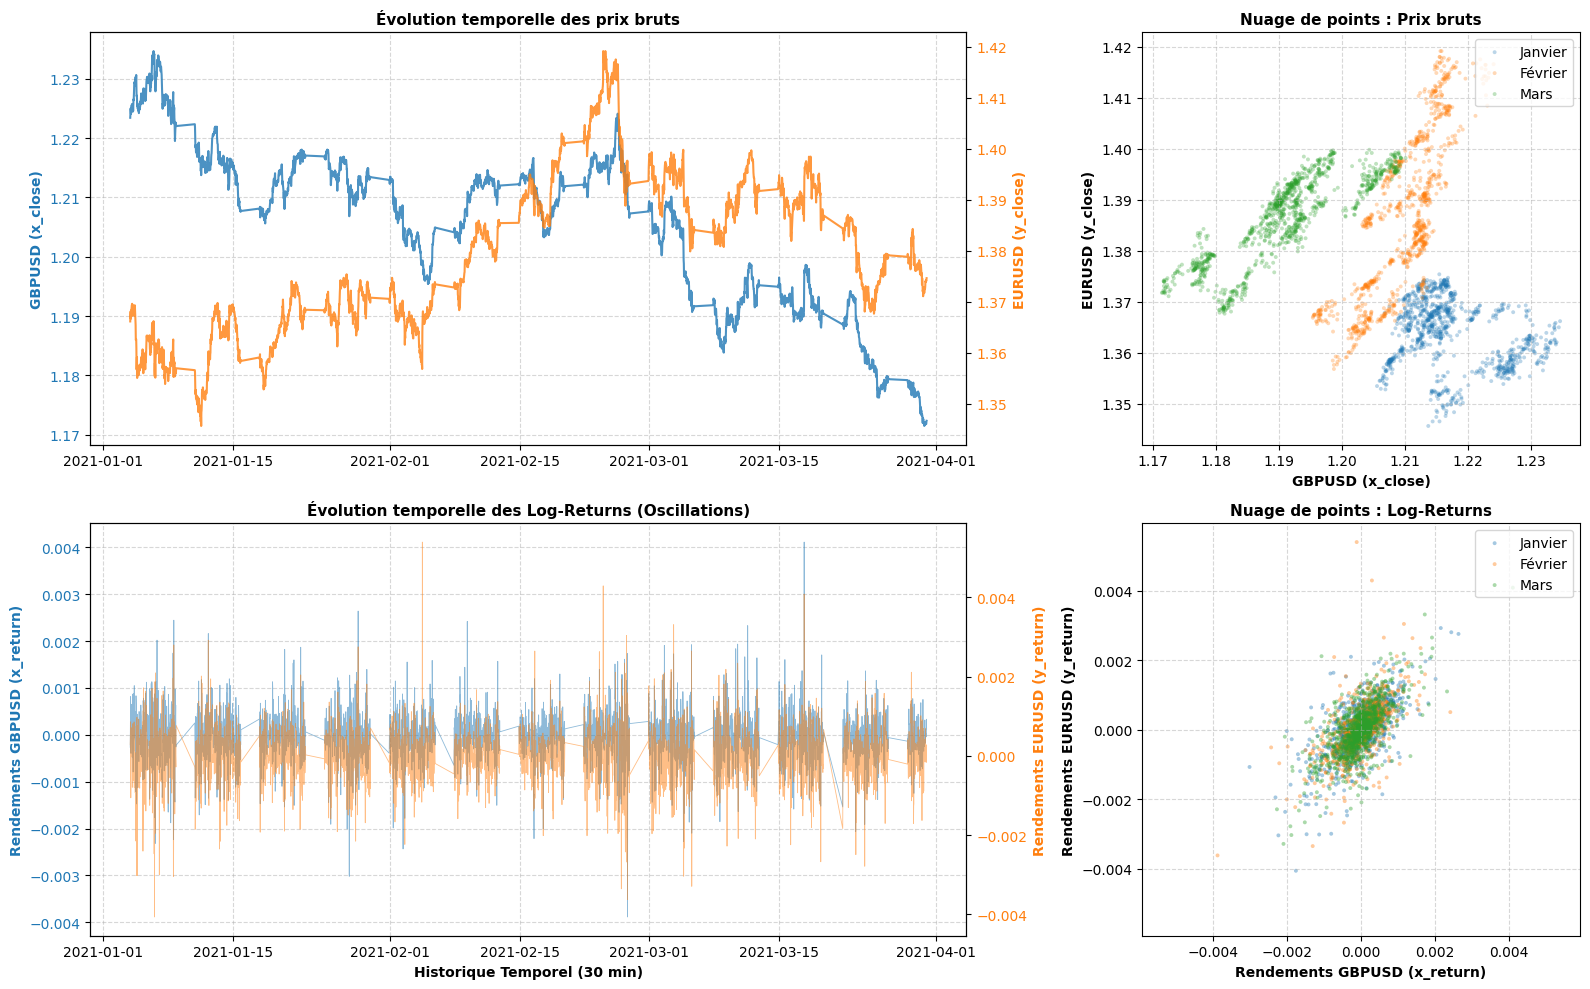

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Sécurité : Conversion de la colonne timestamp en type Datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Séparation des données par mois pour la coloration des scatter plots
janvier = df[df['timestamp'].dt.month == 1]
fevrier = df[df['timestamp'].dt.month == 2]
mars = df[df['timestamp'].dt.month == 3]

# 3. Configuration de la figure (2 lignes, 2 colonnes) avec ratios de largeur (2/3, 1/3)
fig, axs = plt.subplots(2, 2, figsize=(16, 10), gridspec_kw={'width_ratios': [2/3, 1/3], 'height_ratios': [1, 1]})
(ax1_top, ax3_top) = axs[0]  # Ligne 1 : Prix bruts
(ax1_bot, ax3_bot) = axs[1]  # Ligne 2 : Log-Returns

# =====================================================================
# LIGNE 1 : PRIX BRUTS (ANCIEN AFFICHAGE)
# =====================================================================
# À Gauche : Séries Temporelles des prix
color_x = '#1f77b4'
ax1_top.set_ylabel('GBPUSD (x_close)', color=color_x, fontweight='bold')
line1_t = ax1_top.plot(df['timestamp'], df['x_close'], color=color_x, alpha=0.8)
ax1_top.tick_params(axis='y', labelcolor=color_x)
ax1_top.grid(True, linestyle='--', alpha=0.5)
ax1_top.set_title("Évolution temporelle des prix bruts", fontsize=11, fontweight='bold')

ax2_top = ax1_top.twinx()
color_y = '#ff7f0e'
ax2_top.set_ylabel('EURUSD (y_close)', color=color_y, fontweight='bold')
line2_t = ax2_top.plot(df['timestamp'], df['y_close'], color=color_y, alpha=0.8)
ax2_top.tick_params(axis='y', labelcolor=color_y)

# À Droite : Nuage de points des prix
ax3_top.scatter(janvier['x_close'], janvier['y_close'], color='#1f77b4', alpha=0.3, edgecolors='none', s=8, label="Janvier")
ax3_top.scatter(fevrier['x_close'], fevrier['y_close'], color='#ff7f0e', alpha=0.3, edgecolors='none', s=8, label="Février")
ax3_top.scatter(mars['x_close'], mars['y_close'], color='#2ca02c', alpha=0.3, edgecolors='none', s=8, label="Mars")
ax3_top.set_xlabel('GBPUSD (x_close)', fontweight='bold')
ax3_top.set_ylabel('EURUSD (y_close)', fontweight='bold')
ax3_top.set_title("Nuage de points : Prix bruts", fontsize=11, fontweight='bold')
ax3_top.legend(loc='upper right')
ax3_top.grid(True, linestyle='--', alpha=0.5)


# =====================================================================
# LIGNE 2 : LOG-RETURNS (NOUVEL AFFICHAGE COMPLÉMENTAIRE)
# =====================================================================
# À Gauche : Séries Temporelles des rendements
ax1_bot.set_xlabel('Historique Temporel (30 min)', fontweight='bold')
ax1_bot.set_ylabel('Rendements GBPUSD (x_return)', color=color_x, fontweight='bold')
line1_b = ax1_bot.plot(df['timestamp'], df['x_return'], color=color_x, alpha=0.5, linewidth=0.6)
ax1_bot.tick_params(axis='y', labelcolor=color_x)
ax1_bot.grid(True, linestyle='--', alpha=0.5)
ax1_bot.set_title("Évolution temporelle des Log-Returns (Oscillations)", fontsize=11, fontweight='bold')

ax2_bot = ax1_bot.twinx()
ax2_bot.set_ylabel('Rendements EURUSD (y_return)', color=color_y, fontweight='bold')
line2_b = ax2_bot.plot(df['timestamp'], df['y_return'], color=color_y, alpha=0.5, linewidth=0.6)
ax2_bot.tick_params(axis='y', labelcolor=color_y)

# À Droite : Nuage de points des rendements (Recentré et fusionné)
ax3_bot.scatter(janvier['x_return'], janvier['y_return'], color='#1f77b4', alpha=0.4, edgecolors='none', s=8, label="Janvier")
ax3_bot.scatter(fevrier['x_return'], fevrier['y_return'], color='#ff7f0e', alpha=0.4, edgecolors='none', s=8, label="Février")
ax3_bot.scatter(mars['x_return'], mars['y_return'], color='#2ca02c', alpha=0.4, edgecolors='none', s=8, label="Mars")
ax3_bot.set_xlabel('Rendements GBPUSD (x_return)', fontweight='bold')
ax3_bot.set_ylabel('Rendements EURUSD (y_return)', fontweight='bold')
ax3_bot.set_title("Nuage de points : Log-Returns", fontsize=11, fontweight='bold')
ax3_bot.legend(loc='upper right')
ax3_bot.grid(True, linestyle='--', alpha=0.5)

# Centrage géométrique du scatter des rendements autour de (0,0)
max_val = max(df['x_return'].abs().max(), df['y_return'].abs().max()) * 1.1
ax3_bot.set_xlim(-max_val, max_val)
ax3_bot.set_ylim(-max_val, max_val)

plt.tight_layout()
plt.show()


# Split-Train

In [26]:
import numpy as np
import pandas as pd

# 1. Calcul précis de la position pivot à 66% de l'historique
total_rows = len(df)
pivot_index = int(total_rows * 0.66)

# 2. Découpage mathématique par indexation directe (iloc)
df_train = df.iloc[:pivot_index].reset_index(drop=True)
df_test = df.iloc[pivot_index:].reset_index(drop=True)

print("==================================================")
print("📐 DÉCOUPAGE PAR PROPORTION GÉOMÉTRIQUE (66% / 34%)")
print("==================================================")
print(f"🔹 Nombre total de lignes du dataset : {total_rows}")
print(f"📌 Index pivot de la coupure         : {pivot_index}")
print(f"📦 Taille du bloc Entraînement (66%) : {len(df_train)} bougies")
print(f"📦 Taille du bloc Test (34%)         : {len(df_test)} bougies")

# 3. Vérification des plages temporelles réelles générées
print("\n⏱️ Plages de temps réelles :")
print(f"📅 Train : du {df_train['timestamp'].min()} au {df_train['timestamp'].max()}")
print(f"📅 Test  : du {df_test['timestamp'].min()} au {df_test['timestamp'].max()}")


📐 DÉCOUPAGE PAR PROPORTION GÉOMÉTRIQUE (66% / 34%)
🔹 Nombre total de lignes du dataset : 2975
📌 Index pivot de la coupure         : 1963
📦 Taille du bloc Entraînement (66%) : 1963 bougies
📦 Taille du bloc Test (34%)         : 1012 bougies

⏱️ Plages de temps réelles :
📅 Train : du 2021-01-03 22:30:00 au 2021-03-01 19:30:00
📅 Test  : du 2021-03-01 20:00:00 au 2021-03-30 23:30:00


## Train Model

In [28]:
import numpy as np
from enl.linear_model import *

# 1. Extraction des rendements de la période d'entraînement (In-Sample)
# On force le formatage en matrice à 2 dimensions (N observations, 1 colonne)
X_train = df_train['x_return'].values.reshape(-1, 1)
Y_train = df_train['y_return'].values.reshape(-1, 1)

# 2. Instanciation de votre modèle factoriel
model_train = LinearFactorModel()

# 3. Entraînement via la méthode fit() complétée ensemble
beta_vector = model_train.fit(X_train, Y_train)

# Extraction des coefficients sous forme de scalaires
alpha_val = beta_vector[0][0]
beta_val = beta_vector[1][0]

print("==================================================")
print("🎯 MODÈLE ENTRAÎNÉ AVEC SUCCÈS (IN-SAMPLE)")
print("==================================================")
print(f"🔹 Coefficient Alpha (Intercepte)      : {alpha_val:.6f}")
print(f"🔹 Coefficient Beta (Hedge Ratio)     : {beta_val:.6f}")
print(f"🔹 Nombre de bougies d'entraînement    : {len(X_train)}")


🎯 MODÈLE ENTRAÎNÉ AVEC SUCCÈS (IN-SAMPLE)
🔹 Coefficient Alpha (Intercepte)      : 0.000016
🔹 Coefficient Beta (Hedge Ratio)     : 0.831935
🔹 Nombre de bougies d'entraînement    : 1963


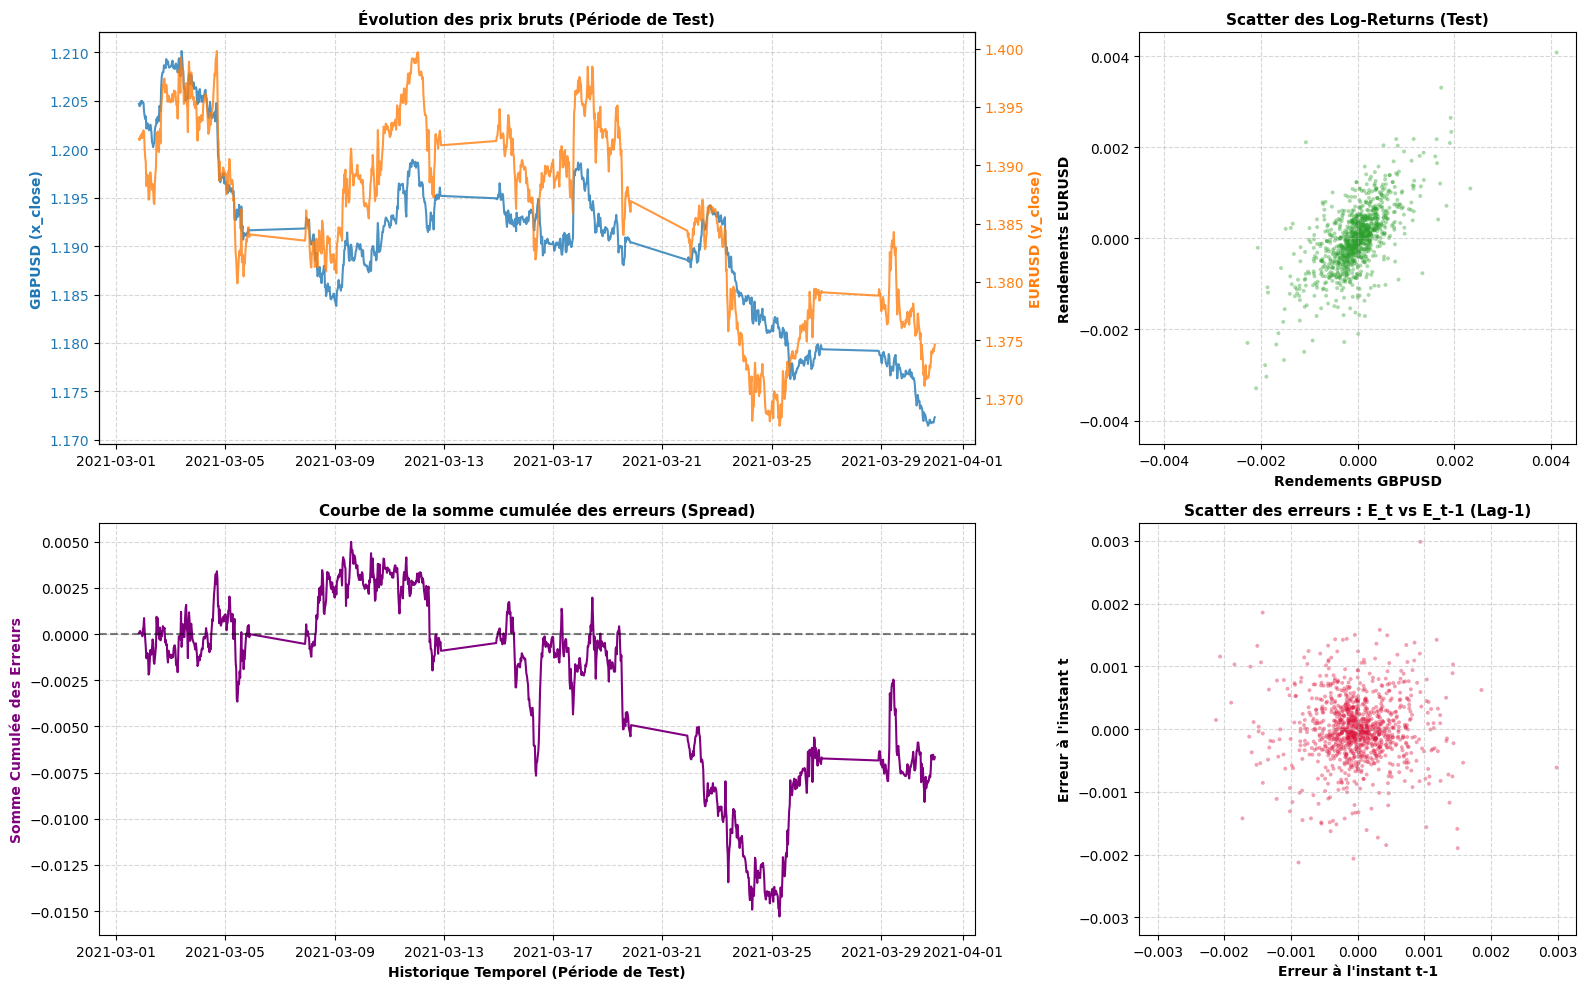

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Extraction des rendements de la période de test
X_test = df_test['x_return'].values
Y_test = df_test['y_return'].values

# 2. Calcul des résidus hors-échantillon (Out-of-Sample) avec les coefficients fixés
# E_test = Y_test - (alpha + beta * X_test)
test_residuals = Y_test - (alpha_val + beta_val * X_test)

# 3. Calcul de la somme cumulée des erreurs pour mesurer la dérive du spread
cum_residuals = np.cumsum(test_residuals)

# 4. Aligner le présent et le passé des résidus pour le scatter plot Lag-1
res_t = test_residuals[1:]
res_lag = test_residuals[:-1]

# 5. Configuration de la figure (2 lignes, 2 colonnes) avec ratios de largeur (2/3, 1/3)
fig, axs = plt.subplots(2, 2, figsize=(16, 10), gridspec_kw={'width_ratios': [2/3, 1/3], 'height_ratios': [1, 1]})
(ax1_top, ax3_top) = axs[0]  # Ligne 1
(ax1_bot, ax3_bot) = axs[1]  # Ligne 2

# =====================================================================
# LIGNE 1 : DONNÉES DE MARCHÉ SUR LA PÉRIODE DE TEST (df_test)
# =====================================================================
# À Gauche : Courbe des prix bruts (Double Axe Y) sur la période de test
color_x = '#1f77b4'
ax1_top.set_ylabel('GBPUSD (x_close)', color=color_x, fontweight='bold')
ax1_top.plot(df_test['timestamp'], df_test['x_close'], color=color_x, alpha=0.8)
ax1_top.tick_params(axis='y', labelcolor=color_x)
ax1_top.grid(True, linestyle='--', alpha=0.5)
ax1_top.set_title("Évolution des prix bruts (Période de Test)", fontsize=11, fontweight='bold')

ax2_top = ax1_top.twinx()
color_y = '#ff7f0e'
ax2_top.set_ylabel('EURUSD (y_close)', color=color_y, fontweight='bold')
ax2_top.plot(df_test['timestamp'], df_test['y_close'], color=color_y, alpha=0.8)
ax2_top.tick_params(axis='y', labelcolor=color_y)

# À Droite : Nuage de points des log-returns du test
ax3_top.scatter(df_test['x_return'], df_test['y_return'], color='#2ca02c', alpha=0.4, edgecolors='none', s=8)
ax3_top.set_xlabel('Rendements GBPUSD', fontweight='bold')
ax3_top.set_ylabel('Rendements EURUSD', fontweight='bold')
ax3_top.set_title("Scatter des Log-Returns (Test)", fontsize=11, fontweight='bold')
ax3_top.grid(True, linestyle='--', alpha=0.5)
max_val_ret = max(df_test['x_return'].abs().max(), df_test['y_return'].abs().max()) * 1.1
ax3_top.set_xlim(-max_val_ret, max_val_ret)
ax3_top.set_ylim(-max_val_ret, max_val_ret)


# =====================================================================
# LIGNE 2 : ANALYSE DES ERREURS DE PRÉDICTION HORS-ÉCHANTILLON
# =====================================================================
# À Gauche : Courbe de la somme cumulée des résidus (Le spread de trading)
ax1_bot.set_xlabel('Historique Temporel (Période de Test)', fontweight='bold')
ax1_bot.set_ylabel('Somme Cumulée des Erreurs', color='purple', fontweight='bold')
ax1_bot.plot(df_test['timestamp'], cum_residuals, color='purple', linewidth=1.5, label='Somme Cumulée')
ax1_bot.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1_bot.grid(True, linestyle='--', alpha=0.5)
ax1_bot.set_title("Courbe de la somme cumulée des erreurs (Spread)", fontsize=11, fontweight='bold')

# À Droite : Nuage de points des erreurs (Lag-1 Autocorrélation)
ax3_bot.scatter(res_lag, res_t, color='crimson', alpha=0.4, edgecolors='none', s=8)
ax3_bot.set_xlabel('Erreur à l\'instant t-1', fontweight='bold')
ax3_bot.set_ylabel('Erreur à l\'instant t', fontweight='bold')
ax3_bot.set_title("Scatter des erreurs : E_t vs E_t-1 (Lag-1)", fontsize=11, fontweight='bold')
ax3_bot.grid(True, linestyle='--', alpha=0.5)
max_val_res = max(np.abs(res_lag).max(), np.abs(res_t).max()) * 1.1
ax3_bot.set_xlim(-max_val_res, max_val_res)
ax3_bot.set_ylim(-max_val_res, max_val_res)

plt.tight_layout()
plt.show()


## Checking hypothesis

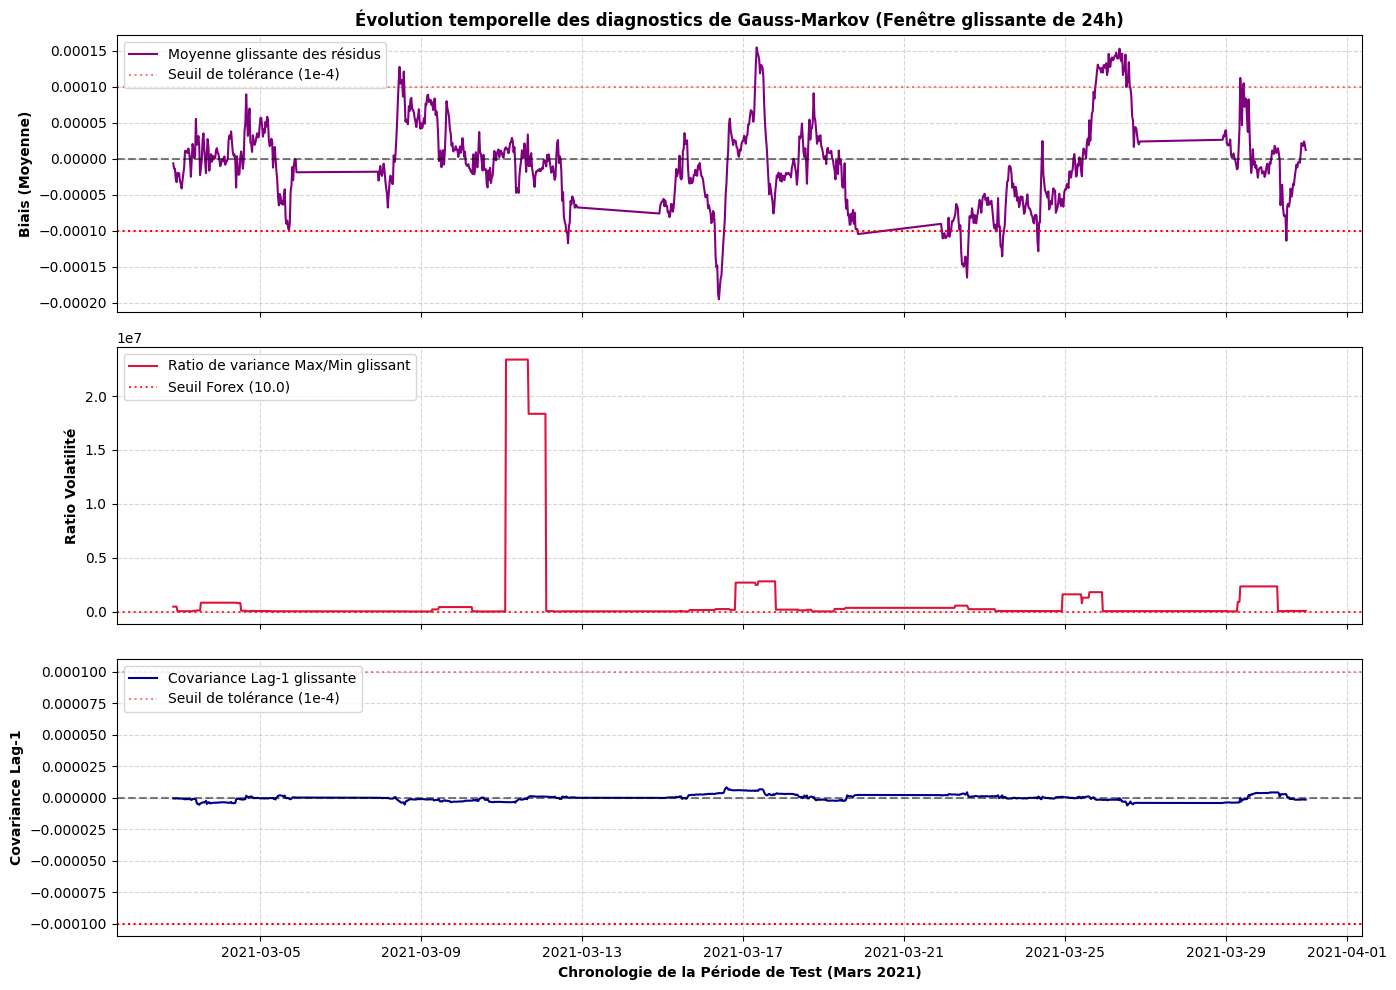

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Définition de la fenêtre glissante : 48 bougies (24 heures de marché)
window_size = 48

# Listes pour stocker l'évolution des métriques
rolling_timestamps = []
rolling_means = []
rolling_vol_ratios = []
rolling_autocorr_covs = []

# 2. Boucle glissante sur les résidus de la période de test
for i in range(window_size, len(test_residuals)):
    # Extraction de la sous-fenêtre courante des résidus
    window_res = test_residuals[i - window_size:i].reshape(-1, 1)

    # Extraction de la sous-fenêtre courante de la matrice X pour le calcul de get_residual_covariance
    X_window_matrix = df_test['x_return'].values[i - window_size:i].reshape(-1, 1)

    # On recrée temporairement une instance fictive pour réutiliser vos méthodes exactes
    tmp_model = LinearFactorModel()
    tmp_model.residuals = window_res
    tmp_model.X_design = np.hstack((np.ones((window_size, 1)), X_window_matrix))

    # Calcul des diagnostics exacts développés ensemble
    mean_val = np.mean(window_res)

    variances_window = np.diag(tmp_model.get_residual_covariance())
    vol_ratio = np.max(variances_window) / (np.min(variances_window) if np.min(variances_window) > 0 else 1e-12)

    res_t = window_res[1:]
    res_lag = window_res[:-1]
    lag_1_cov = np.dot(res_t.T, res_lag)[0][0]

    # Stockage
    rolling_timestamps.append(df_test['timestamp'].iloc[i])
    rolling_means.append(mean_val)
    rolling_vol_ratios.append(vol_ratio)
    rolling_autocorr_covs.append(lag_1_cov)

# 3. Construction graphique : 3 sous-graphiques empilés verticalement
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Graphique 1 : Évolution du Biais (Moyenne des résidus)
ax1.plot(rolling_timestamps, rolling_means, color='purple', label='Moyenne glissante des résidus')
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.axhline(1e-4, color='red', linestyle=':', alpha=0.5, label='Seuil de tolérance (1e-4)')
ax1.axhline(-1e-4, color='red', linestyle=':')
ax1.set_ylabel('Biais (Moyenne)', fontweight='bold')
ax1.set_title("Évolution temporelle des diagnostics de Gauss-Markov (Fenêtre glissante de 24h)", fontsize=12, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# Graphique 2 : Évolution de l'Hétéroscédasticité (Ratio Max/Min)
ax2.plot(rolling_timestamps, rolling_vol_ratios, color='crimson', label='Ratio de variance Max/Min glissant')
ax2.axhline(10.0, color='red', linestyle=':', alpha=0.8, label='Seuil Forex (10.0)')
ax2.set_ylabel('Ratio Volatilité', fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

# Graphique 3 : Évolution de l'Autocorrélation (Covariance Lag-1)
ax3.plot(rolling_timestamps, rolling_autocorr_covs, color='darkblue', label='Covariance Lag-1 glissante')
ax3.axhline(0, color='black', linestyle='--', alpha=0.5)
ax3.axhline(1e-4, color='red', linestyle=':', alpha=0.5, label='Seuil de tolérance (1e-4)')
ax3.axhline(-1e-4, color='red', linestyle=':')
ax3.set_xlabel('Chronologie de la Période de Test (Mars 2021)', fontweight='bold')
ax3.set_ylabel('Covariance Lag-1', fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# Walk-Forward

In [51]:
from enl.data_feed import *
import pandas as pd
import numpy as np

# 1. Chargement de l'année 2022 complète
start_2022 = '2022-01-01'
end_2022 = '2022-12-31'

df_2022 = load_pair_time_bars('GBPUSD', 'EURUSD', start_2022, end_2022, '30min', ['close'], use_optim=True, use_thread=True)
df_2022 = df_2022[['timestamp', 'x_close', 'y_close']]

# 2. Calcul immédiat des log-returns pour travailler sur des données saines
df_2022['timestamp'] = pd.to_datetime(df_2022['timestamp'])
df_2022['x_return'] = np.log(df_2022['x_close']) - np.log(df_2022['x_close'].shift(1))
df_2022['y_return'] = np.log(df_2022['y_close']) - np.log(df_2022['y_close'].shift(1))
df_2022 = df_2022.dropna().reset_index(drop=True)

print(f"✅ Données 2022 chargées : {len(df_2022)} bougies prêtes pour le Walk-Forward.")
df_2022

[WARNING] File "/home/user/perso/trading/alphalab/data/GBPUSD/raw/GBPUSD_TICKS_2023_12_24.parquet" not found
[WARNING] File "/home/user/perso/trading/alphalab/data/EURUSD/raw/EURUSD_TICKS_2023_12_31.parquet" not found
[WARNING] File "/home/user/perso/trading/alphalab/data/GBPUSD/raw/GBPUSD_TICKS_2023_12_31.parquet" not found
[WARNING] 4994 bars have been dropped
[WARNING] 4996 bars have been dropped
[WARNING] Found 4 gaps in pair (DROP)
[WARNING] Dropped 4 unsync-able datetime
[INFO] Pair "GBPUSD (X) / EURUSD (Y)" loaded (12378 bars)
✅ Données 2022 chargées : 12377 bougies prêtes pour le Walk-Forward.


,timestamp,x_close,y_close,x_return,y_return
0,2023-01-01 23:30:00,1.210100,1.070610,0.001091,0.000570
1,2023-01-02 00:00:00,1.209670,1.070005,-0.000355,-0.000565
2,2023-01-02 00:30:00,1.208825,1.070705,-0.000699,0.000654
3,2023-01-02 01:00:00,1.209515,1.070645,0.000571,-0.000056
4,2023-01-02 01:30:00,1.208530,1.070025,-0.000815,-0.000579
...,...,...,...,...,...
12372,2023-12-29 19:30:00,1.274605,1.104080,0.000718,-0.000018
12373,2023-12-29 20:00:00,1.275550,1.104760,0.000741,0.000616
12374,2023-12-29 20:30:00,1.274820,1.104110,-0.000572,-0.000589
12375,2023-12-29 21:00:00,1.273875,1.103645,-0.000742,-0.000421


## Testing

In [52]:
# Listes pour collecter l'historique hors-échantillon reconstitué (fenêtre de 1 mois)
wf_timestamps_1m = []
wf_residuals_1m = []
wf_steps_summary_1m = []

# On commence au mois 2 (Février) car le mois 1 (Janvier) sert de premier entraînement
for target_month in range(2, 13):
    # Entraînement uniquement sur le mois précédent immédiat
    train_month = target_month - 1

    # 1. Isolation des blocs temporels d'un mois
    df_train_wf = df_2022[df_2022['timestamp'].dt.month == train_month]
    df_test_wf = df_2022[df_2022['timestamp'].dt.month == target_month]

    if len(df_test_wf) == 0 or len(df_train_wf) == 0:
        continue

    # 2. Extraction des matrices (Format strict 2D pour la méthode fit)
    X_train_wf = df_train_wf['x_return'].values.reshape(-1, 1)
    Y_train_wf = df_train_wf['y_return'].values.reshape(-1, 1)

    # Format strict 1D pour l'application directe sur le test
    X_test_wf = df_test_wf['x_return'].values.flatten()
    Y_test_wf = df_test_wf['y_return'].values.flatten()

    # 3. Entraînement du modèle sur 1 mois glissant
    model_wf = LinearFactorModel()
    beta_vector = model_wf.fit(X_train_wf, Y_train_wf)
    alpha_wf = float(beta_vector[0][0])
    beta_wf = float(beta_vector[1][0])

    # 4. Calcul des résidus hors-échantillon forcés à plat (.flatten)
    test_res_wf = Y_test_wf - (alpha_wf + beta_wf * X_test_wf)
    test_res_wf = test_res_wf.flatten().tolist()

    # 5. Stockage des résultats
    wf_timestamps_1m.extend(df_test_wf['timestamp'].tolist())
    wf_residuals_1m.extend(test_res_wf)

    wf_steps_summary_1m.append({
        'Mois Test': target_month,
        'Mois Train': train_month,
        'Alpha (In-Sample)': alpha_wf,
        'Beta (In-Sample)': beta_wf,
        'Taille Test': len(df_test_wf)
    })

# Conversion sécurisée en tableaux numpy d'éléments de même taille
wf_residuals_1m = np.array(wf_residuals_1m, dtype=float)
wf_cum_residuals_1m = np.cumsum(wf_residuals_1m)

print("============================================================")
print("📊 NOUVEAU TABLEAU DE PARAMÈTRES (FENÊTRE DE 1 MOIS)")
print("============================================================")
df_summary_1m = pd.DataFrame(wf_steps_summary_1m)
print(df_summary_1m.to_string(index=False))


📊 NOUVEAU TABLEAU DE PARAMÈTRES (FENÊTRE DE 1 MOIS)
 Mois Test  Mois Train  Alpha (In-Sample)  Beta (In-Sample)  Taille Test
         2           1           0.000003          0.645604          960
         3           2          -0.000013          0.617483         1094
         4           3           0.000007          0.683558          956
         5           4           0.000002          0.778164         1096
         6           5          -0.000021          0.714037         1042
         7           6           0.000006          0.706863         1004
         8           7           0.000001          0.621653         1096
         9           8          -0.000005          0.675434          994
        10           9           0.000001          0.699537         1052
        11          10           0.000004          0.758783         1054
        12          11           0.000002          0.695621          972


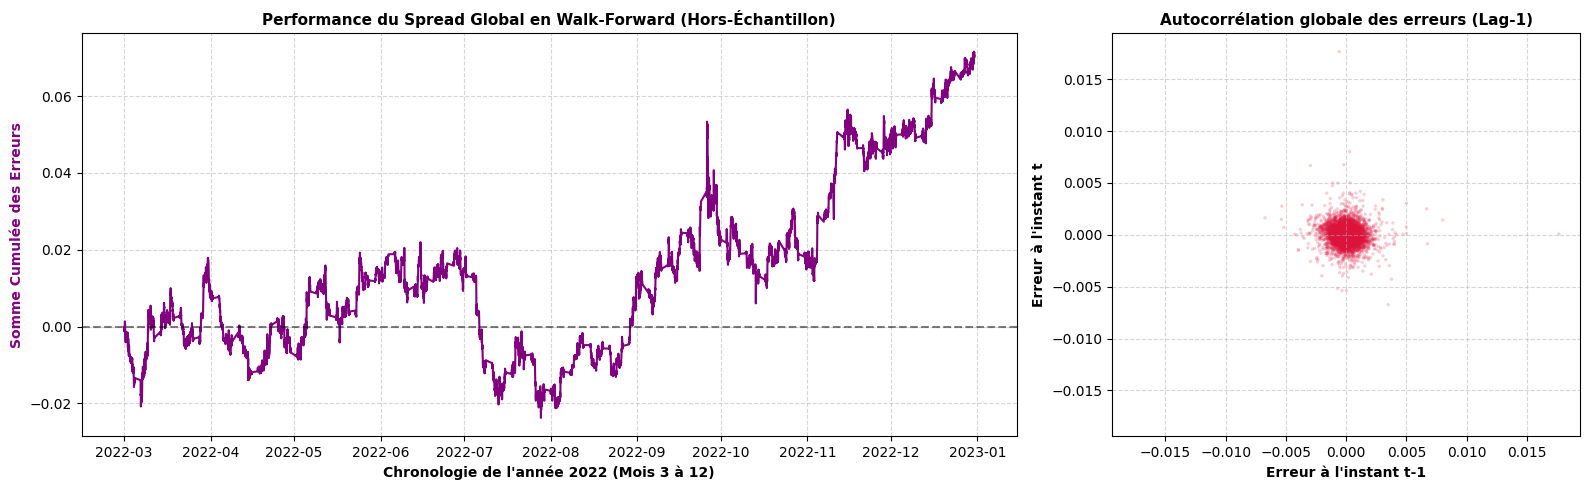

📊 Moyenne globale de l'erreur en Walk-Forward : 6.75e-06


In [53]:
import matplotlib.pyplot as plt

# Configuration de la figure sur une seule ligne (2/3 et 1/3)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2, 1]})

# 1. PANNEAU DE GAUCHE : Somme cumulée des résidus Walk-Forward 2022
ax1.plot(wf_timestamps, wf_cum_residuals, color='purple', linewidth=1.5, label='Somme Cumulée WF')
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('Chronologie de l\'année 2022 (Mois 3 à 12)', fontweight='bold')
ax1.set_ylabel('Somme Cumulée des Erreurs', color='purple', fontweight='bold')
ax1.set_title("Performance du Spread Global en Walk-Forward (Hors-Échantillon)", fontsize=11, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. PANNEAU DE DROITE : Scatter Plot global des résidus Walk-Forward
ax2.scatter(wf_residuals[:-1], wf_residuals[1:], color='crimson', alpha=0.2, edgecolors='none', s=6)
ax2.set_xlabel('Erreur à l\'instant t-1', fontweight='bold')
ax2.set_ylabel('Erreur à l\'instant t', fontweight='bold')
ax2.set_title("Autocorrélation globale des erreurs (Lag-1)", fontsize=11, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

# Centrage du scatter plot
max_res_val = max(np.abs(wf_residuals).max() * 1.1, 1e-5)
ax2.set_xlim(-max_res_val, max_res_val)
ax2.set_ylim(-max_res_val, max_res_val)

plt.tight_layout()
plt.show()

# Petite métrique statistique finale pour votre rapport
print(f"📊 Moyenne globale de l'erreur en Walk-Forward : {np.mean(wf_residuals):.2e}")


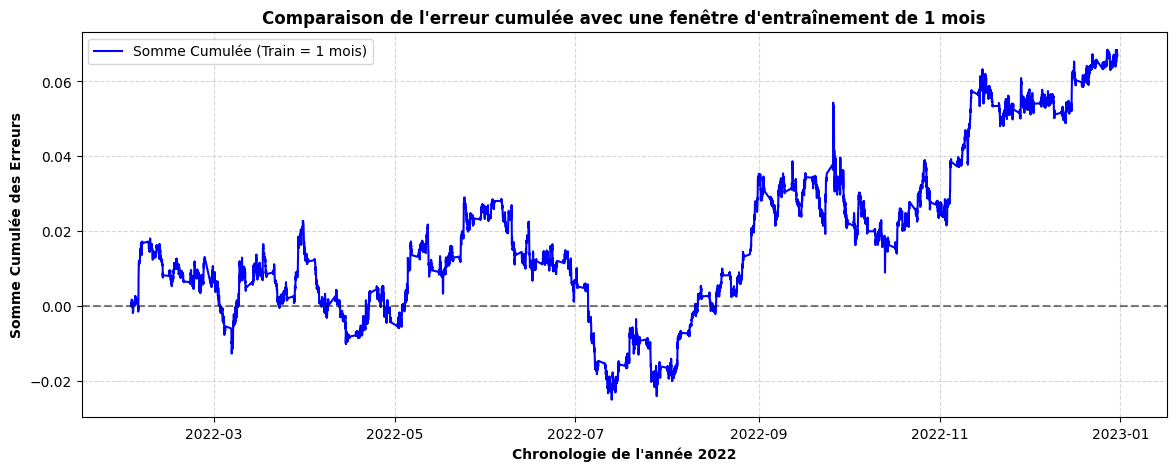

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
# Nouvelle courbe (1 mois de train)
plt.plot(wf_timestamps_1m, wf_cum_residuals_1m, color='blue', linewidth=1.5, label='Somme Cumulée (Train = 1 mois)')
# Ligne de référence
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.xlabel('Chronologie de l\'année 2022', fontweight='bold')
plt.ylabel('Somme Cumulée des Erreurs', fontweight='bold')
plt.title("Comparaison de l'erreur cumulée avec une fenêtre d'entraînement de 1 mois", fontsize=12, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


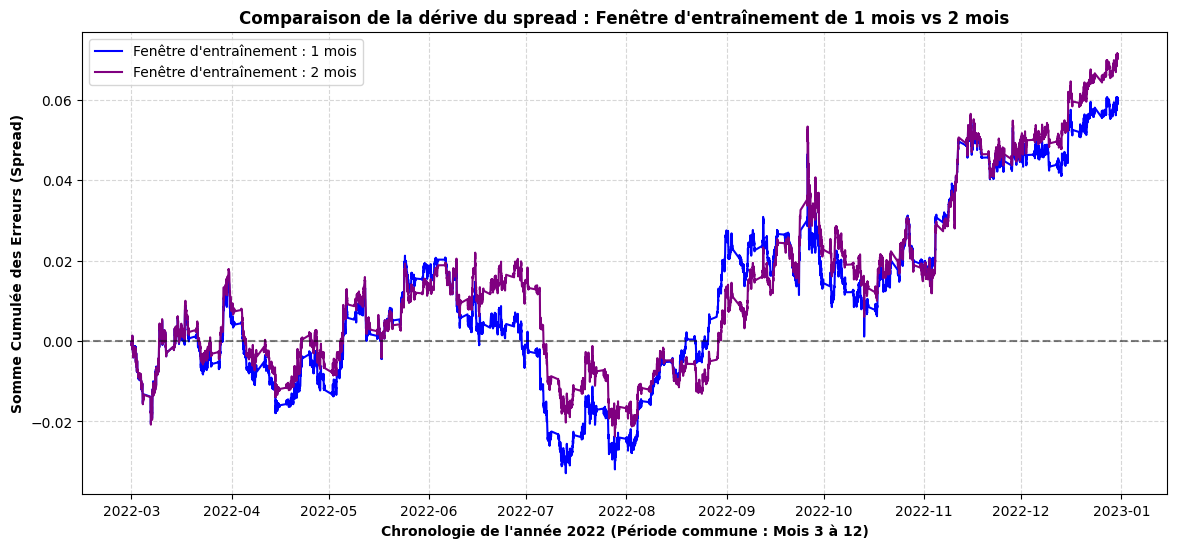

📊 Erreur cumulée finale (1 mois de train) : 0.0593
📊 Erreur cumulée finale (2 mois de train) : 0.0705


In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Conversion des résultats en DataFrames pour faciliter l'alignement temporel
df_wf_2m = pd.DataFrame({'timestamp': wf_timestamps, 'res_2m': wf_residuals})
df_wf_1m = pd.DataFrame({'timestamp': wf_timestamps_1m, 'res_1m': wf_residuals_1m})

# 2. Fusion des deux historiques sur la plage commune (à partir de Mars 2022)
df_comp = pd.merge(df_wf_1m, df_wf_2m, on='timestamp', how='inner')

# 3. Recalcul des sommes cumulées sur cette période commune pour démarrer à 0 au même instant
df_comp['cum_res_1m'] = np.cumsum(df_comp['res_1m'])
df_comp['cum_res_2m'] = np.cumsum(df_comp['res_2m'])

# 4. Traçage du graphique
plt.figure(figsize=(14, 6))

# Courbe 1 mois (Bleu)
plt.plot(df_comp['timestamp'], df_comp['cum_res_1m'], color='blue', linewidth=1.5, label='Fenêtre d\'entraînement : 1 mois')
# Courbe 2 mois (Violet)
plt.plot(df_comp['timestamp'], df_comp['cum_res_2m'], color='purple', linewidth=1.5, label='Fenêtre d\'entraînement : 2 mois')

# Ligne de référence à 0
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Habillage factuel
plt.xlabel('Chronologie de l\'année 2022 (Période commune : Mois 3 à 12)', fontweight='bold')
plt.ylabel('Somme Cumulée des Erreurs (Spread)', fontweight='bold')
plt.title("Comparaison de la dérive du spread : Fenêtre d'entraînement de 1 mois vs 2 mois", fontsize=12, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Métriques factuelles de fin de période
final_error_1m = df_comp['cum_res_1m'].iloc[-1]
final_error_2m = df_comp['cum_res_2m'].iloc[-1]
print(f"📊 Erreur cumulée finale (1 mois de train) : {final_error_1m:.4f}")
print(f"📊 Erreur cumulée finale (2 mois de train) : {final_error_2m:.4f}")


/tmp/ipykernel_74094/3354058415.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lag_1_cov = float(np.dot(res_t.T, res_lag)) / N_window


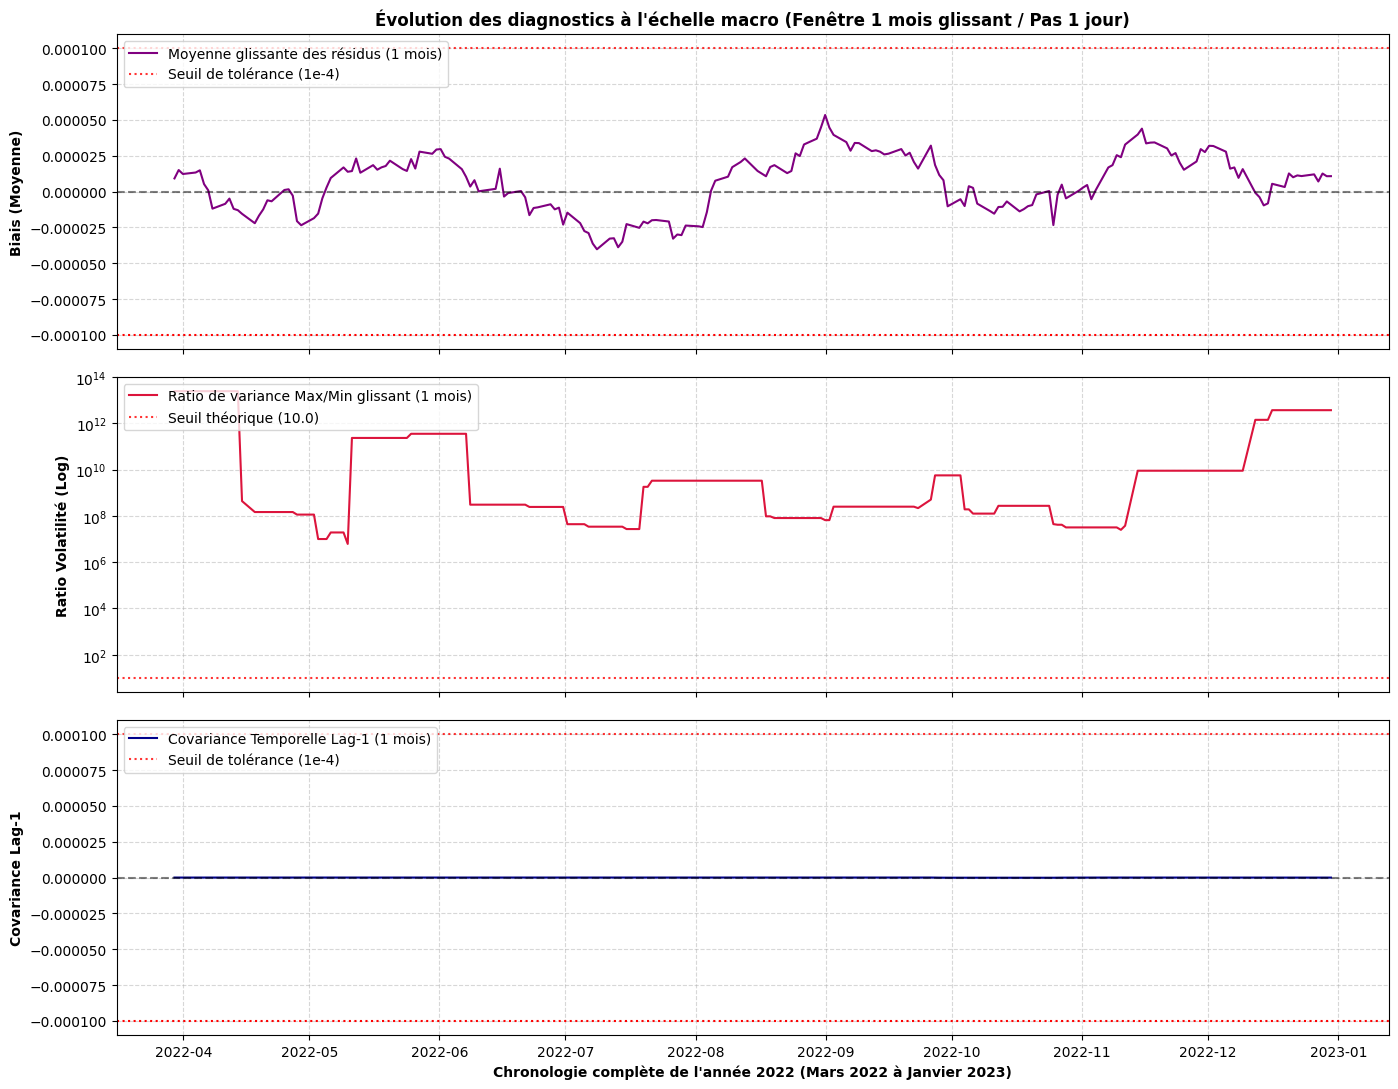

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Alignement et fusion sécurisée des données depuis le dataset global
df_comp['timestamp'] = pd.to_datetime(df_comp['timestamp'])
df_2022['timestamp'] = pd.to_datetime(df_2022['timestamp'])

df_macro_diag = pd.merge(
    df_comp[['timestamp', 'res_1m']],
    df_2022[['timestamp', 'x_return']],
    on='timestamp',
    how='inner'
)

# Extraction des vecteurs depuis le DataFrame fusionné
res_1m_full = df_macro_diag['res_1m'].values
x_return_full = df_macro_diag['x_return'].values
timestamps_full = df_macro_diag['timestamp'].tolist()

# CONFIGURATION ÉCHELLE MACRO :
# Fenêtre : 1 mois de trading (~1000 bougies de 30 min)
window_size = 1000
# Pas de déplacement : 1 jour de trading (48 bougies de 30 min)
step_size = 48

rolling_wf_timestamps = []
rolling_wf_means = []
rolling_wf_vol_ratios = []
rolling_wf_autocorr_covs = []

# 2. Boucle de calcul glissant par pas de 1 jour (48 bougies)
for i in range(window_size, len(res_1m_full), step_size):
    # Extraction des blocs d'un mois
    window_res = res_1m_full[i - window_size:i].reshape(-1, 1)
    X_window = x_return_full[i - window_size:i].reshape(-1, 1)

    # Instance de diagnostic dédiée
    tmp_model = LinearFactorModel()
    tmp_model.residuals = window_res
    tmp_model.X_design = np.hstack((np.ones((window_size, 1)), X_window))

    # Métrique H2 : Biais (Moyenne sur 1 mois)
    mean_val = np.mean(window_res)

    # Métrique H3 : Homoscédasticité (Ratio Max/Min sur 1 mois)
    variances_window = np.diag(tmp_model.get_residual_covariance())
    vol_ratio = np.max(variances_window) / (np.min(variances_window) if np.min(variances_window) > 0 else 1e-12)

    # Métrique H5 : Autocorrélation corrigée (Covariance Lag-1 sur 1 mois)
    res_t = window_res[1:]
    res_lag = window_res[:-1]
    N_window = len(res_t)
    lag_1_cov = float(np.dot(res_t.T, res_lag)) / N_window

    # Stockage
    rolling_wf_timestamps.append(timestamps_full[i])
    rolling_wf_means.append(mean_val)
    rolling_wf_vol_ratios.append(vol_ratio)
    rolling_wf_autocorr_covs.append(lag_1_cov)

# 3. Construction des 3 graphiques empilés
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Graphique 1 : Évolution du Biais macro
ax1.plot(rolling_wf_timestamps, rolling_wf_means, color='purple', label='Moyenne glissante des résidus (1 mois)')
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.axhline(1e-4, color='red', linestyle=':', alpha=0.8, label='Seuil de tolérance (1e-4)')
ax1.axhline(-1e-4, color='red', linestyle=':')
ax1.set_ylabel('Biais (Moyenne)', fontweight='bold')
ax1.set_title("Évolution des diagnostics à l'échelle macro (Fenêtre 1 mois glissant / Pas 1 jour)", fontsize=12, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# Graphique 2 : Évolution de l'Hétéroscédasticité macro
ax2.plot(rolling_wf_timestamps, rolling_wf_vol_ratios, color='crimson', label='Ratio de variance Max/Min glissant (1 mois)')
ax2.axhline(10.0, color='red', linestyle=':', alpha=0.8, label='Seuil théorique (10.0)')
ax2.set_ylabel('Ratio Volatilité (Log)', fontweight='bold')
ax2.set_yscale('log')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

# Graphique 3 : Évolution de l'Autocorrélation macro
ax3.plot(rolling_wf_timestamps, rolling_wf_autocorr_covs, color='darkblue', label='Covariance Temporelle Lag-1 (1 mois)')
ax3.axhline(0, color='black', linestyle='--', alpha=0.5)
ax3.axhline(1e-4, color='red', linestyle=':', alpha=0.8, label='Seuil de tolérance (1e-4)')
ax3.axhline(-1e-4, color='red', linestyle=':')
ax3.set_xlabel('Chronologie complète de l\'année 2022 (Mars 2022 à Janvier 2023)', fontweight='bold')
ax3.set_ylabel('Covariance Lag-1', fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


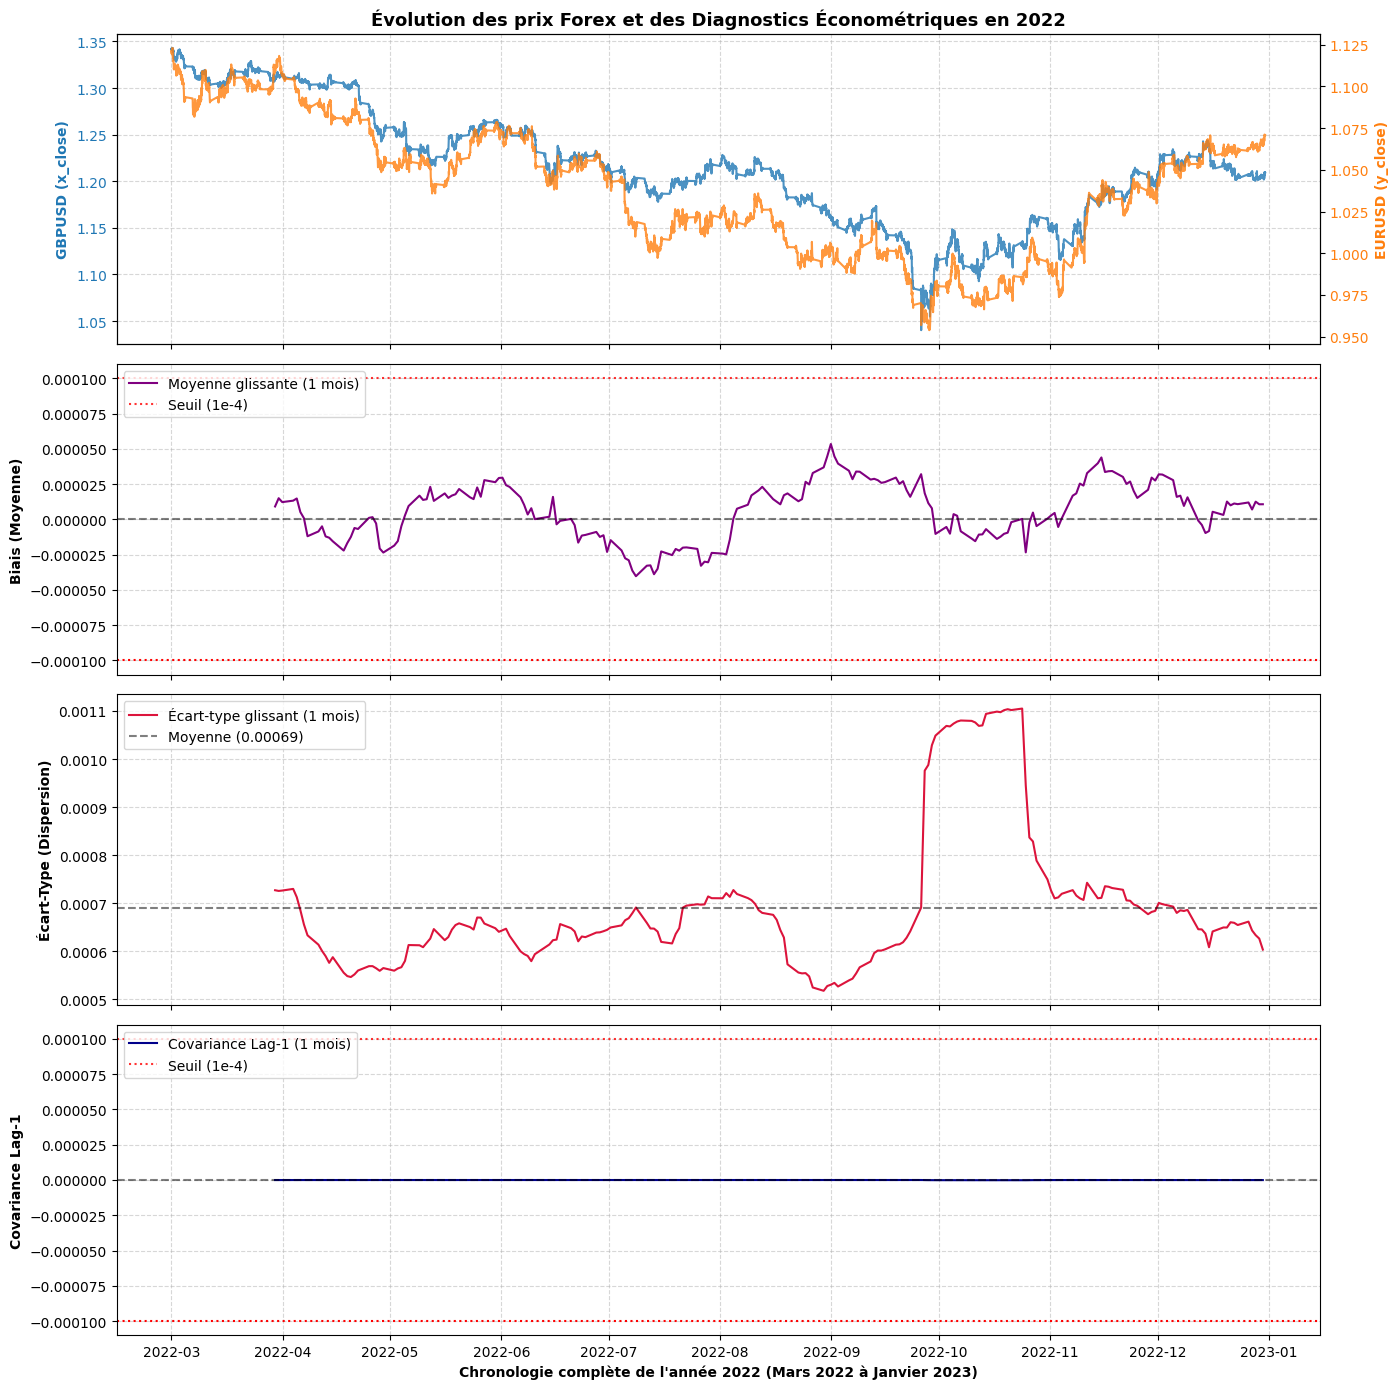

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Alignement et fusion sécurisée des données de marché historiques
df_macro_diag['timestamp'] = pd.to_datetime(df_macro_diag['timestamp'])
df_2022['timestamp'] = pd.to_datetime(df_2022['timestamp'])

# Jointure pour récupérer les prix bruts synchronisés sur les résidus
df_full_plot = pd.merge(
    df_macro_diag[['timestamp', 'res_1m']],
    df_2022[['timestamp', 'x_close', 'y_close']],
    on='timestamp',
    how='inner'
)

# Extraction des tableaux pour la boucle et le graphique
res_1m_full = df_full_plot['res_1m'].values
timestamps_full = df_full_plot['timestamp'].tolist()

window_size = 1000
step_size = 48

rolling_timestamps_full = []
rolling_means_full = []
rolling_stds_full = []
rolling_autocorr_covs_full = []

# 2. Boucle de calcul glissant (Fenêtre 1 mois / Pas 1 jour)
for i in range(window_size, len(res_1m_full), step_size):
    window_res = res_1m_full[i - window_size:i]

    mean_val = np.mean(window_res)
    std_val = np.std(window_res)

    res_t = window_res[1:]
    res_lag = window_res[:-1]
    lag_1_cov = np.mean(res_t * res_lag)

    rolling_timestamps_full.append(timestamps_full[i])
    rolling_means_full.append(mean_val)
    rolling_stds_full.append(std_val)
    rolling_autocorr_covs_full.append(lag_1_cov)

# 3. Construction graphique : 4 sous-graphiques empilés verticalement
fig, (ax0, ax1, ax2, ax3) = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# ---------------------------------------------------------------------
# PANEL 0 (NOUVEAU) : Évolution des Prix Bruts (Double Axe Y)
# ---------------------------------------------------------------------
color_x = '#1f77b4'  # Bleu
ax0.plot(df_full_plot['timestamp'], df_full_plot['x_close'], color=color_x, alpha=0.8, label='GBPUSD (x_close)')
ax0.set_ylabel('GBPUSD (x_close)', color=color_x, fontweight='bold')
ax0.tick_params(axis='y', labelcolor=color_x)
ax0.grid(True, linestyle='--', alpha=0.5)
ax0.set_title("Évolution des prix Forex et des Diagnostics Économétriques en 2022", fontsize=13, fontweight='bold')

ax0_twin = ax0.twinx()
color_y = '#ff7f0e'  # Orange
ax0_twin.plot(df_full_plot['timestamp'], df_full_plot['y_close'], color=color_y, alpha=0.8, label='EURUSD (y_close)')
ax0_twin.set_ylabel('EURUSD (y_close)', color=color_y, fontweight='bold')
ax0_twin.tick_params(axis='y', labelcolor=color_y)

# ---------------------------------------------------------------------
# PANEL 1 : Hypothèse 2 (Biais / Moyenne glissante)
# ---------------------------------------------------------------------
ax1.plot(rolling_timestamps_full, rolling_means_full, color='purple', label='Moyenne glissante (1 mois)')
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.axhline(1e-4, color='red', linestyle=':', alpha=0.8, label='Seuil (1e-4)')
ax1.axhline(-1e-4, color='red', linestyle=':')
ax1.set_ylabel('Biais (Moyenne)', fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# ---------------------------------------------------------------------
# PANEL 2 : Hypothèse 3 (Homoscédasticité / Écart-type glissant)
# ---------------------------------------------------------------------
ax2.plot(rolling_timestamps_full, rolling_stds_full, color='crimson', label='Écart-type glissant (1 mois)')
mean_historical_std = np.mean(rolling_stds_full)
ax2.axhline(mean_historical_std, color='black', linestyle='--', alpha=0.5, label=f'Moyenne ({mean_historical_std:.5f})')
ax2.set_ylabel('Écart-Type (Dispersion)', fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

# ---------------------------------------------------------------------
# PANEL 3 : Hypothèse 5 (Autocorrélation / Covariance Lag-1)
# ---------------------------------------------------------------------
ax3.plot(rolling_timestamps_full, rolling_autocorr_covs_full, color='darkblue', label='Covariance Lag-1 (1 mois)')
ax3.axhline(0, color='black', linestyle='--', alpha=0.5)
ax3.axhline(1e-4, color='red', linestyle=':', alpha=0.8, label='Seuil (1e-4)')
ax3.axhline(-1e-4, color='red', linestyle=':')
ax3.set_xlabel('Chronologie complète de l\'année 2022 (Mars 2022 à Janvier 2023)', fontweight='bold')
ax3.set_ylabel('Covariance Lag-1', fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# Fixed (2023)

In [54]:
from enl.data_feed import *
import pandas as pd
import numpy as np

# 1. Chargement de l'année 2023 complète
start_2023 = '2023-01-01'
end_2023 = '2023-12-31'

df_2023 = load_pair_time_bars('GBPUSD', 'EURUSD', start_2023, end_2023, '30min', ['close'], use_optim=True, use_thread=True)
df_2023 = df_2023[['timestamp', 'x_close', 'y_close']]

# 2. Calcul immédiat des log-returns
df_2023['timestamp'] = pd.to_datetime(df_2023['timestamp'])
df_2023['x_return'] = np.log(df_2023['x_close']) - np.log(df_2023['x_close'].shift(1))
df_2023['y_return'] = np.log(df_2023['y_close']) - np.log(df_2023['y_close'].shift(1))
df_2023 = df_2023.dropna().reset_index(drop=True)

print(f"✅ Données 2023 chargées : {len(df_2023)} bougies prêtes pour le Walk-Forward.")
df_2023

[WARNING] File "/home/user/perso/trading/alphalab/data/EURUSD/raw/EURUSD_TICKS_2023_12_31.parquet" not found
[WARNING] File "/home/user/perso/trading/alphalab/data/GBPUSD/raw/GBPUSD_TICKS_2023_12_24.parquet" not found
[WARNING] File "/home/user/perso/trading/alphalab/data/GBPUSD/raw/GBPUSD_TICKS_2023_12_31.parquet" not found
[WARNING] 4996 bars have been dropped
[WARNING] 4994 bars have been dropped
[WARNING] Found 4 gaps in pair (DROP)
[WARNING] Dropped 4 unsync-able datetime
[INFO] Pair "GBPUSD (X) / EURUSD (Y)" loaded (12378 bars)
✅ Données 2023 chargées : 12377 bougies prêtes pour le Walk-Forward.


,timestamp,x_close,y_close,x_return,y_return
0,2023-01-01 23:30:00,1.210100,1.070610,0.001091,0.000570
1,2023-01-02 00:00:00,1.209670,1.070005,-0.000355,-0.000565
2,2023-01-02 00:30:00,1.208825,1.070705,-0.000699,0.000654
3,2023-01-02 01:00:00,1.209515,1.070645,0.000571,-0.000056
4,2023-01-02 01:30:00,1.208530,1.070025,-0.000815,-0.000579
...,...,...,...,...,...
12372,2023-12-29 19:30:00,1.274605,1.104080,0.000718,-0.000018
12373,2023-12-29 20:00:00,1.275550,1.104760,0.000741,0.000616
12374,2023-12-29 20:30:00,1.274820,1.104110,-0.000572,-0.000589
12375,2023-12-29 21:00:00,1.273875,1.103645,-0.000742,-0.000421


In [55]:
wf_timestamps_2023 = []
wf_zscores_2023 = []
wf_summary_2023 = []

# Boucle de validation glissante pour l'année 2023
for target_month in range(4, 13):
    # Fenêtre fixe de 3 mois d'entraînement
    train_months = [target_month - 3, target_month - 2, target_month - 1]

    # Isolation des blocs via pandas
    df_train_wf = df_2023[df_2023['timestamp'].dt.month.isin(train_months)]
    df_test_wf = df_2023[df_2023['timestamp'].dt.month == target_month]

    if len(df_test_wf) == 0 or len(df_train_wf) == 0:
        continue

    # Extraction des matrices pour le modèle
    X_train_wf = df_train_wf['x_return'].values.reshape(-1, 1)
    Y_train_wf = df_train_wf['y_return'].values.reshape(-1, 1)

    X_test_wf = df_test_wf['x_return'].values.flatten()
    Y_test_wf = df_test_wf['y_return'].values.flatten()

    # 1. Entraînement sur la fenêtre In-Sample de 3 mois
    model_wf = LinearFactorModel()
    beta_vector = model_wf.fit(X_train_wf, Y_train_wf)
    alpha_wf = float(beta_vector[0])
    beta_wf = float(beta_vector[1])

    # 2. Métriques de dispersion In-Sample (Entraînement)
    train_residuals = model_wf.residuals.flatten()
    mu_train = np.mean(train_residuals)
    sigma_train = np.std(train_residuals)

    # 3. Calcul des résidus bruts Out-of-Sample (Test)
    test_res_raw = Y_test_wf - (alpha_wf + beta_wf * X_test_wf)

    # 4. Normalisation : Calcul du Z-score hors-échantillon
    test_zscores = (test_res_raw - mu_train) / (sigma_train if sigma_train > 0 else 1e-12)

    # Stockage
    wf_timestamps_2023.extend(df_test_wf['timestamp'].tolist())
    wf_zscores_2023.extend(test_zscores.flatten().tolist())

    wf_summary_2023.append({
        'Mois Test': target_month,
        'Beta (3 mois train)': beta_wf,
        'Sigma Train': sigma_train,
        'Taille Test': len(df_test_wf)
    })

wf_zscores_2023 = np.array(wf_zscores_2023)

print("============================================================")
print("📊 COMPILATION DU WALK-FORWARD EN Z-SCORE (2023)")
print("============================================================")
print(pd.DataFrame(wf_summary_2023).to_string(index=False))


📊 COMPILATION DU WALK-FORWARD EN Z-SCORE (2023)
 Mois Test  Beta (3 mois train)  Sigma Train  Taille Test
         4             0.647022     0.000501          956
         5             0.674351     0.000474         1096
         6             0.716904     0.000447         1042
         7             0.734101     0.000391         1004
         8             0.679532     0.000410         1096
         9             0.666348     0.000412          994
        10             0.663843     0.000401         1052
        11             0.713640     0.000372         1054
        12             0.720541     0.000353          972


/tmp/ipykernel_74094/1295728934.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alpha_wf = float(beta_vector[0])
/tmp/ipykernel_74094/1295728934.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta_wf = float(beta_vector[1])


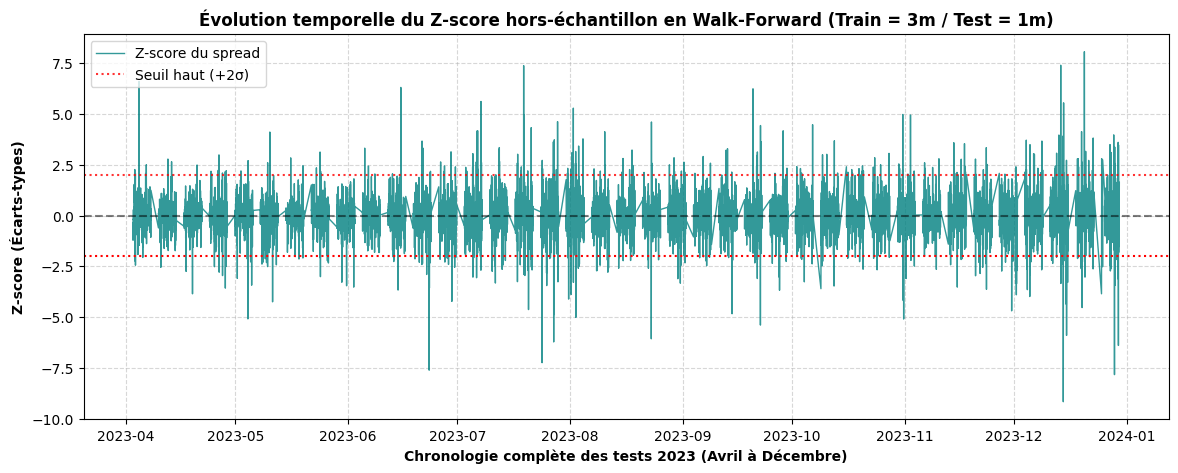

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(wf_timestamps_2023, wf_zscores_2023, color='teal', linewidth=1, alpha=0.8, label='Z-score du spread')

# Lignes de référence statistiques de Gauss
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axhline(2, color='red', linestyle=':', alpha=0.8, label='Seuil haut (+2σ)')
plt.axhline(-2, color='red', linestyle=':')

plt.xlabel('Chronologie complète des tests 2023 (Avril à Décembre)', fontweight='bold')
plt.ylabel('Z-score (Écarts-types)', fontweight='bold')
plt.title("Évolution temporelle du Z-score hors-échantillon en Walk-Forward (Train = 3m / Test = 1m)", fontsize=12, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## Z-score signal

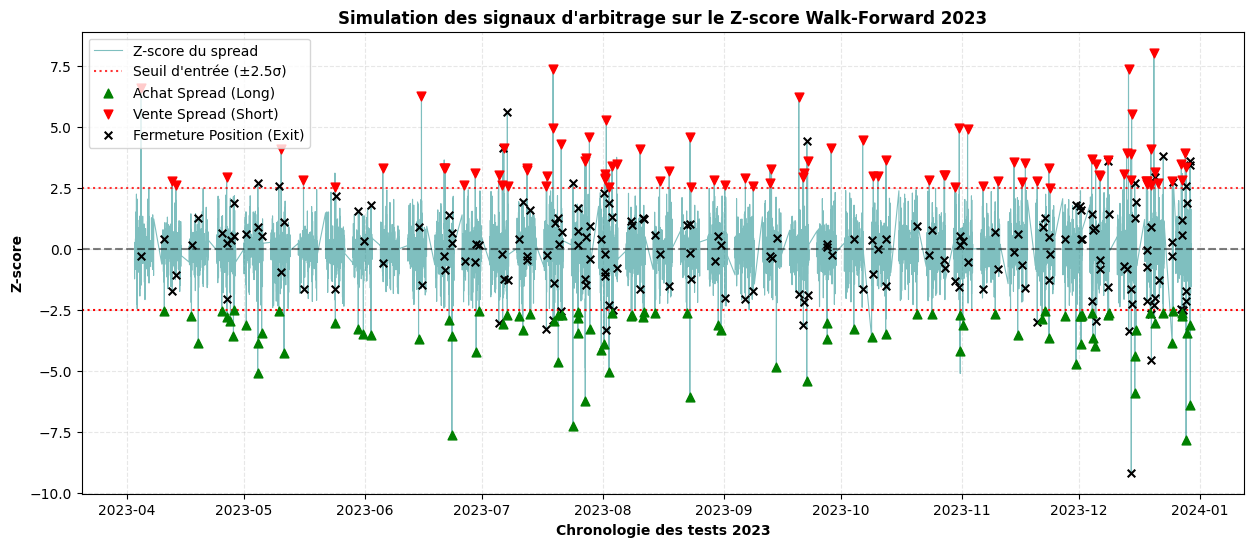

📊 BILAN EX-POST DES SIGNAUX GÉNÉRÉS EN 2023
🔹 Nombre d'entrées à l'Achat (Long) : 94
🔹 Nombre d'entrées à la Vente (Short) : 92
🔹 Nombre de fermetures de positions   : 186


In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Définition des seuils de la stratégie
entry_threshold = 2.5
exit_threshold = 0.0

# Initialisation des variables d'état du robot
position = 0  # 0 = Pas de trade, 1 = Long (Achat du spread), -1 = Short (Vente du spread)
signals_timestamps = []
signals_zscores = []
signals_types = []  # 'BUY', 'SELL', 'EXIT'

# 2. Boucle de détection des signaux sur le vecteur de Z-score
for i in range(len(wf_zscores_2023)):
    z = wf_zscores_2023[i]
    t = wf_timestamps_2023[i]

    # ÉTAT : Le robot n'est pas en position -> Recherche d'une anomalie
    if position == 0:
        if z >= entry_threshold:
            position = -1  # On vend le spread trop cher
            signals_timestamps.append(t)
            signals_zscores.append(z)
            signals_types.append('SELL')
        elif z <= -entry_threshold:
            position = 1   # On achète le spread trop bas
            signals_timestamps.append(t)
            signals_zscores.append(z)
            signals_types.append('BUY')

    # ÉTAT : Le robot est déjà en position -> Attente du retour à la moyenne (Zéro)
    elif position == 1:  # On était Long
        if z >= exit_threshold:
            position = 0   # Sortie de position
            signals_timestamps.append(t)
            signals_zscores.append(z)
            signals_types.append('EXIT_LONG')

    elif position == -1: # On était Short
        if z <= exit_threshold:
            position = 0   # Sortie de position
            signals_timestamps.append(t)
            signals_zscores.append(z)
            signals_types.append('EXIT_SHORT')

# 3. Création du DataFrame des signaux pour analyse factuelle
df_signals = pd.DataFrame({
    'timestamp': signals_timestamps,
    'z_score': signals_zscores,
    'type': signals_types
})

# 4. Construction du graphique avec superposition des signaux
plt.figure(figsize=(15, 6))
plt.plot(wf_timestamps_2023, wf_zscores_2023, color='teal', linewidth=0.8, alpha=0.5, label='Z-score du spread')

# Bornes de la stratégie
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axhline(entry_threshold, color='red', linestyle=':', alpha=0.8, label=f'Seuil d\'entrée (±{entry_threshold}σ)')
plt.axhline(-entry_threshold, color='red', linestyle=':')

# Superposition des points de signaux d'entrée
buys = df_signals[df_signals['type'] == 'BUY']
sells = df_signals[df_signals['type'] == 'SELL']
exits = df_signals[df_signals['type'].str.contains('EXIT')]

plt.scatter(buys['timestamp'], buys['z_score'], color='green', marker='^', s=40, label='Achat Spread (Long)', zorder=5)
plt.scatter(sells['timestamp'], sells['z_score'], color='red', marker='v', s=40, label='Vente Spread (Short)', zorder=5)
plt.scatter(exits['timestamp'], exits['z_score'], color='black', marker='x', s=30, label='Fermeture Position (Exit)', zorder=4)

plt.xlabel('Chronologie des tests 2023', fontweight='bold')
plt.ylabel('Z-score', fontweight='bold')
plt.title("Simulation des signaux d'arbitrage sur le Z-score Walk-Forward 2023", fontsize=12, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Affichage des métriques de l'exercice
print("============================================================")
print("📊 BILAN EX-POST DES SIGNAUX GÉNÉRÉS EN 2023")
print("============================================================")
print(f"🔹 Nombre d'entrées à l'Achat (Long) : {len(buys)}")
print(f"🔹 Nombre d'entrées à la Vente (Short) : {len(sells)}")
print(f"🔹 Nombre de fermetures de positions   : {len(exits)}")


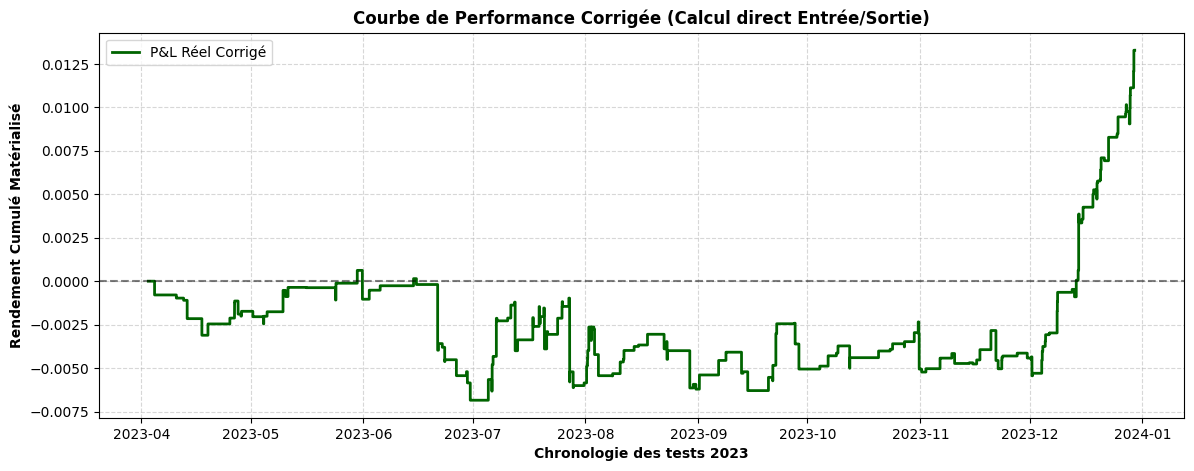

In [59]:
# 1. Extraction des prix bruts alignés pour la période de test
x_close_test = df_test_all['x_close'].values
y_close_test = df_test_all['y_close'].values

current_position = 0
closed_pnl_timeline = np.zeros(len(wf_zscores_2023))
trade_history = []
trade_counter = 0

# 2. Boucle corrigée (Calcul direct Entrée / Sortie)
for i in range(len(wf_zscores_2023)):
    z = wf_zscores_2023[i]

    if current_position == 0:
        # ENTRÉE SHORT
        if z >= entry_threshold:
            current_position = -1
            t_entry = timestamps_test[i]
            x_entry = x_close_test[i]
            y_entry = y_close_test[i]
            beta_entry = beta_t[i] # On fige le Beta à l'entrée
        # ENTRÉE LONG
        elif z <= -entry_threshold:
            current_position = 1
            t_entry = timestamps_test[i]
            x_entry = x_close_test[i]
            y_entry = y_close_test[i]
            beta_entry = beta_t[i] # On fige le Beta à l'entrée

    elif current_position == 1 and z >= exit_threshold:
        # SORTIE LONG : Gain = (ln(Y_sort) - ln(Y_ent)) - Beta * (ln(X_sort) - ln(X_ent))
        current_position = 0
        trade_return = (np.log(y_close_test[i]) - np.log(y_entry)) - beta_entry * (np.log(x_close_test[i]) - np.log(x_entry))
        closed_pnl_timeline[i] = trade_return
        trade_counter += 1
        trade_history.append({'ID': trade_counter, 'Type': 'LONG', 'Entrée': t_entry, 'Sortie': timestamps_test[i], 'P&L (%)': trade_return * 100})

    elif current_position == -1 and z <= exit_threshold:
        # SORTIE SHORT : Gain = - [ (ln(Y_sort) - ln(Y_ent)) - Beta * (ln(X_sort) - ln(X_ent)) ]
        current_position = 0
        trade_return = -((np.log(y_close_test[i]) - np.log(y_entry)) - beta_entry * (np.log(x_close_test[i]) - np.log(x_entry)))
        closed_pnl_timeline[i] = trade_return
        trade_counter += 1
        trade_history.append({'ID': trade_counter, 'Type': 'SHORT', 'Entrée': t_entry, 'Sortie': timestamps_test[i], 'P&L (%)': trade_return * 100})

pnl_matrialise_cumule = np.cumsum(closed_pnl_timeline)

# Affichage graphique
plt.figure(figsize=(14, 5))
plt.step(timestamps_test, pnl_matrialise_cumule, color='darkgreen', where='post', linewidth=2, label='P&L Réel Corrigé')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Chronologie des tests 2023', fontweight='bold')
plt.ylabel('Rendement Cumulé Matérialisé', fontweight='bold')
plt.title("Courbe de Performance Corrigée (Calcul direct Entrée/Sortie)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


[WARNING] File "/home/user/perso/trading/alphalab/data/EURUSD/raw/EURUSD_TICKS_2023_12_31.parquet" not found
[WARNING] File "/home/user/perso/trading/alphalab/data/GBPUSD/raw/GBPUSD_TICKS_2023_12_24.parquet" not found
[WARNING] File "/home/user/perso/trading/alphalab/data/GBPUSD/raw/GBPUSD_TICKS_2023_12_31.parquet" not found
[WARNING] 4994 bars have been dropped
[WARNING] 4996 bars have been dropped
[WARNING] Found 4 gaps in pair (DROP)
[WARNING] Dropped 4 unsync-able datetime
[INFO] Pair "GBPUSD (X) / EURUSD (Y)" loaded (12378 bars)


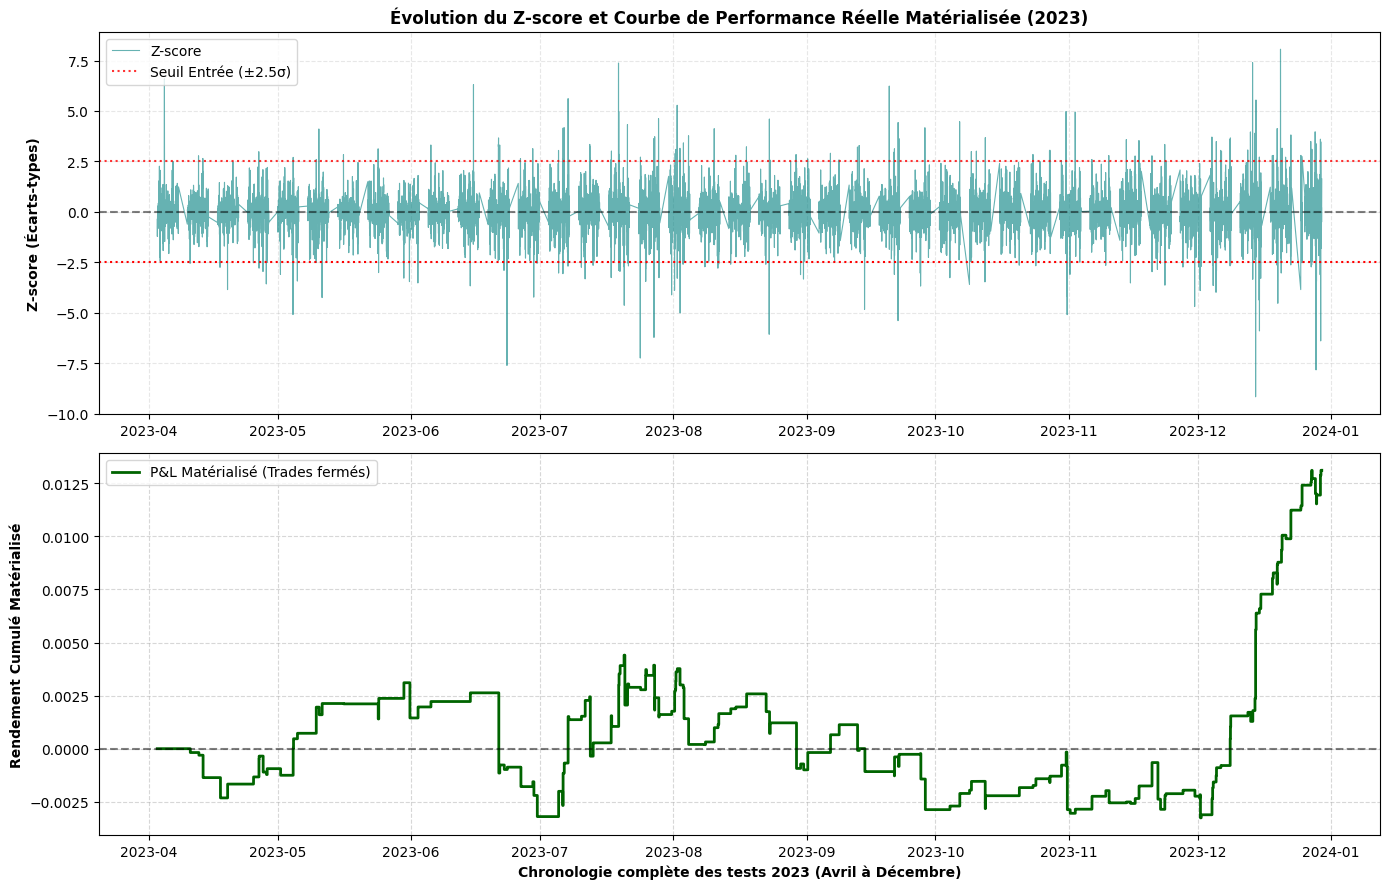


📊 JOURNAL COMPTABLE DES OPÉRATIONS TRADÉES
 ID  Type              Entrée              Sortie P&L (%)
  1  LONG 2023-04-10 13:30:00 2023-04-10 14:30:00 -0.018%
  2 SHORT 2023-04-12 12:30:00 2023-04-12 14:30:00 -0.013%
  3 SHORT 2023-04-13 12:30:00 2023-04-13 14:00:00 -0.106%
  4  LONG 2023-04-17 12:30:00 2023-04-17 15:00:00 -0.096%
  5  LONG 2023-04-19 06:30:00 2023-04-19 07:00:00  0.065%
  6  LONG 2023-04-25 07:00:00 2023-04-25 07:30:00  0.034%
  7 SHORT 2023-04-26 13:00:00 2023-04-26 14:00:00  0.084%
  8  LONG 2023-04-26 14:30:00 2023-04-26 15:00:00  0.014%
  9  LONG 2023-04-27 12:30:00 2023-04-27 13:30:00 -0.075%
 10  LONG 2023-04-28 07:00:00 2023-04-28 08:30:00 -0.012%
 11  LONG 2023-04-28 11:30:00 2023-04-28 12:00:00  0.028%
 12  LONG 2023-05-01 14:00:00 2023-05-01 15:00:00 -0.031%
 13  LONG 2023-05-04 12:30:00 2023-05-04 13:00:00  0.128%
 14  LONG 2023-05-04 14:30:00 2023-05-04 15:00:00  0.044%
 15  LONG 2023-05-05 12:30:00 2023-05-05 13:00:00  0.026%
 16  LONG 2023-05-09 21:30:0

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from enl.data_feed import load_pair_time_bars

# =====================================================================
# 1. ARCHITECTURE DU MODÈLE FACTORIEL (Moteur OLS complet)
# =====================================================================
class LinearFactorModel:
    def __init__(self):
        self.beta = None
        self.residuals = None
        self.X_design = None

    def fit(self, X: np.ndarray, Y: np.ndarray) -> np.ndarray:
        T, num_features = X.shape
        self.X_design = np.hstack((np.ones((T, 1)), X))
        cross_product = np.dot(self.X_design.T, self.X_design)
        det_cross = np.linalg.det(cross_product)
        if np.abs(det_cross) < 1e-12:
            raise ValueError("LinAlgError: Singular matrix detected. Multicollinearity violates Hypothesis 4.")
        cross_inverse = np.linalg.inv(cross_product)
        projection_vector = np.dot(self.X_design.T, Y)
        self.beta = np.dot(cross_inverse, projection_vector)
        self.residuals = Y - np.dot(self.X_design, self.beta)
        return self.beta

    def get_residual_covariance(self) -> np.ndarray:
        if self.residuals is None:
            raise ValueError("Model must be fitted before running diagnostics.")
        return np.outer(self.residuals, self.residuals)

# =====================================================================
# 2. CHARGEMENT ET PRÉPARATION DES DONNÉES 2023
# =====================================================================
start_2023 = '2023-01-01'
end_2023 = '2023-12-31'

df_2023 = load_pair_time_bars('GBPUSD', 'EURUSD', start_2023, end_2023, '30min', ['close'], use_optim=True, use_thread=True)
df_2023 = df_2023[['timestamp', 'x_close', 'y_close']]

df_2023['timestamp'] = pd.to_datetime(df_2023['timestamp'])
df_2023['x_return'] = np.log(df_2023['x_close']) - np.log(df_2023['x_close'].shift(1))
df_2023['y_return'] = np.log(df_2023['y_close']) - np.log(df_2023['y_close'].shift(1))
df_2023 = df_2023.dropna().reset_index(drop=True)

# =====================================================================
# 3. MOTEUR WALK-FORWARD (Train = 3 mois / Test = 1 mois) & Z-SCORE
# =====================================================================
wf_timestamps_2023 = []
wf_zscores_2023 = []
wf_summary_2023 = []

for target_month in range(4, 13):
    train_months = [target_month - 3, target_month - 2, target_month - 1]

    df_train_wf = df_2023[df_2023['timestamp'].dt.month.isin(train_months)]
    df_test_wf = df_2023[df_2023['timestamp'].dt.month == target_month]

    if len(df_test_wf) == 0 or len(df_train_wf) == 0:
        continue

    X_train_wf = df_train_wf['x_return'].values.reshape(-1, 1)
    Y_train_wf = df_train_wf['y_return'].values.reshape(-1, 1)

    X_test_wf = df_test_wf['x_return'].values.flatten()
    Y_test_wf = df_test_wf['y_return'].values.flatten()

    # Entraînement In-Sample
    model_wf = LinearFactorModel()
    beta_vector = model_wf.fit(X_train_wf, Y_train_wf)
    alpha_wf = float(beta_vector[0][0])
    beta_wf = float(beta_vector[1][0])

    train_residuals = model_wf.residuals.flatten()
    mu_train = np.mean(train_residuals)
    sigma_train = np.std(train_residuals)

    # Résidus bruts Out-of-Sample
    test_res_raw = Y_test_wf - (alpha_wf + beta_wf * X_test_wf)

    # Calcul du Z-score
    test_zscores = (test_res_raw - mu_train) / (sigma_train if sigma_train > 0 else 1e-12)

    wf_timestamps_2023.extend(df_test_wf['timestamp'].tolist())
    wf_zscores_2023.extend(test_zscores.flatten().tolist())

    wf_summary_2023.append({
        'Mois Test': target_month,
        'Beta (3m)': beta_wf,
        'Sigma Train': sigma_train
    })

wf_zscores_2023 = np.array(wf_zscores_2023)

# =====================================================================
# 4. SIMULATION COMPTABLE DES SIGNAUX & P&L SANS BIAIS DE TIMING
# =====================================================================
df_test_all = df_2023[df_2023['timestamp'].isin(wf_timestamps_2023)].reset_index(drop=True)
x_close_test = df_test_all['x_close'].values
y_close_test = df_test_all['y_close'].values
timestamps_test = df_test_all['timestamp'].tolist()

# Vecteur de couverture (Beta) par bougie
beta_t = np.zeros(len(df_test_all))
for step in wf_summary_2023:
    beta_t[df_test_all['timestamp'].dt.month == step['Mois Test']] = step['Beta (3m)']

abnormal_threshold = 5.0
entry_threshold = 2.5
exit_threshold = 0.0

current_position = 0
closed_pnl_timeline = np.zeros(len(wf_zscores_2023))
trade_history = []
trade_counter = 0

for i in range(len(wf_zscores_2023)):
    z = wf_zscores_2023[i]

    if current_position == 0:
        # ENTRÉE SHORT (Vente EURUSD, Achat GBPUSD)
        if z >= entry_threshold and z < abnormal_threshold:
            current_position = -1
            t_entry = timestamps_test[i]
            x_entry = x_close_test[i]
            y_entry = y_close_test[i]
            beta_entry = beta_t[i]
        # ENTRÉE LONG (Achat EURUSD, Vente GBPUSD)
        elif z <= -entry_threshold and z > -abnormal_threshold:
            current_position = 1
            t_entry = timestamps_test[i]
            x_entry = x_close_test[i]
            y_entry = y_close_test[i]
            beta_entry = beta_t[i]

    elif current_position == 1 and z >= exit_threshold:
        # FERMETURE DU LONG (Calcul direct par les prix bruts)
        current_position = 0
        trade_return = (np.log(y_close_test[i]) - np.log(y_entry)) - beta_entry * (np.log(x_close_test[i]) - np.log(x_entry))
        closed_pnl_timeline[i] = trade_return
        trade_counter += 1
        trade_history.append({'ID': trade_counter, 'Type': 'LONG', 'Entrée': t_entry, 'Sortie': timestamps_test[i], 'P&L (%)': trade_return * 100})

    elif current_position == -1 and z <= exit_threshold:
        # FERMETURE DU SHORT (Calcul direct par les prix bruts)
        current_position = 0
        trade_return = -((np.log(y_close_test[i]) - np.log(y_entry)) - beta_entry * (np.log(x_close_test[i]) - np.log(x_entry)))
        closed_pnl_timeline[i] = trade_return
        trade_counter += 1
        trade_history.append({'ID': trade_counter, 'Type': 'SHORT', 'Entrée': t_entry, 'Sortie': timestamps_test[i], 'P&L (%)': trade_return * 100})

pnl_matrialise_cumule = np.cumsum(closed_pnl_timeline)

# =====================================================================
# 5. AFFICHAGE DES RÉSULTATS GRAPHIDIQUES COHÉRENTS
# =====================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

# Graphique 1 : Le Z-score de référence
ax1.plot(wf_timestamps_2023, wf_zscores_2023, color='teal', linewidth=0.8, alpha=0.6, label='Z-score')
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.axhline(entry_threshold, color='red', linestyle=':', alpha=0.8, label=f'Seuil Entrée (±{entry_threshold}σ)')
ax1.axhline(-entry_threshold, color='red', linestyle=':')
ax1.set_ylabel('Z-score (Écarts-types)', fontweight='bold')
ax1.set_title("Évolution du Z-score et Courbe de Performance Réelle Matérialisée (2023)", fontsize=12, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.3)

# Graphique 2 : Le P&L Comptable Strict
ax2.step(timestamps_test, pnl_matrialise_cumule, color='darkgreen', where='post', linewidth=2, label='P&L Matérialisé (Trades fermés)')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Chronologie complète des tests 2023 (Avril à Décembre)', fontweight='bold')
ax2.set_ylabel('Rendement Cumulé Matérialisé', fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Journal condensé dans le terminal
df_trades = pd.DataFrame(trade_history)
print("\n============================================================")
print("📊 JOURNAL COMPTABLE DES OPÉRATIONS TRADÉES")
print("============================================================")
if not df_trades.empty:
    print(df_trades.to_string(index=False, formatters={'P&L (%)': '{:,.3f}%'.format}))
    print(f"\n🔹 Transactions bouclées : {len(df_trades)} | Rendement Net : {pnl_matrialise_cumule[-1] * 100:.2f} %")
else:
    print("Aucune transaction n'a atteint l'objectif de sortie.")


## R2

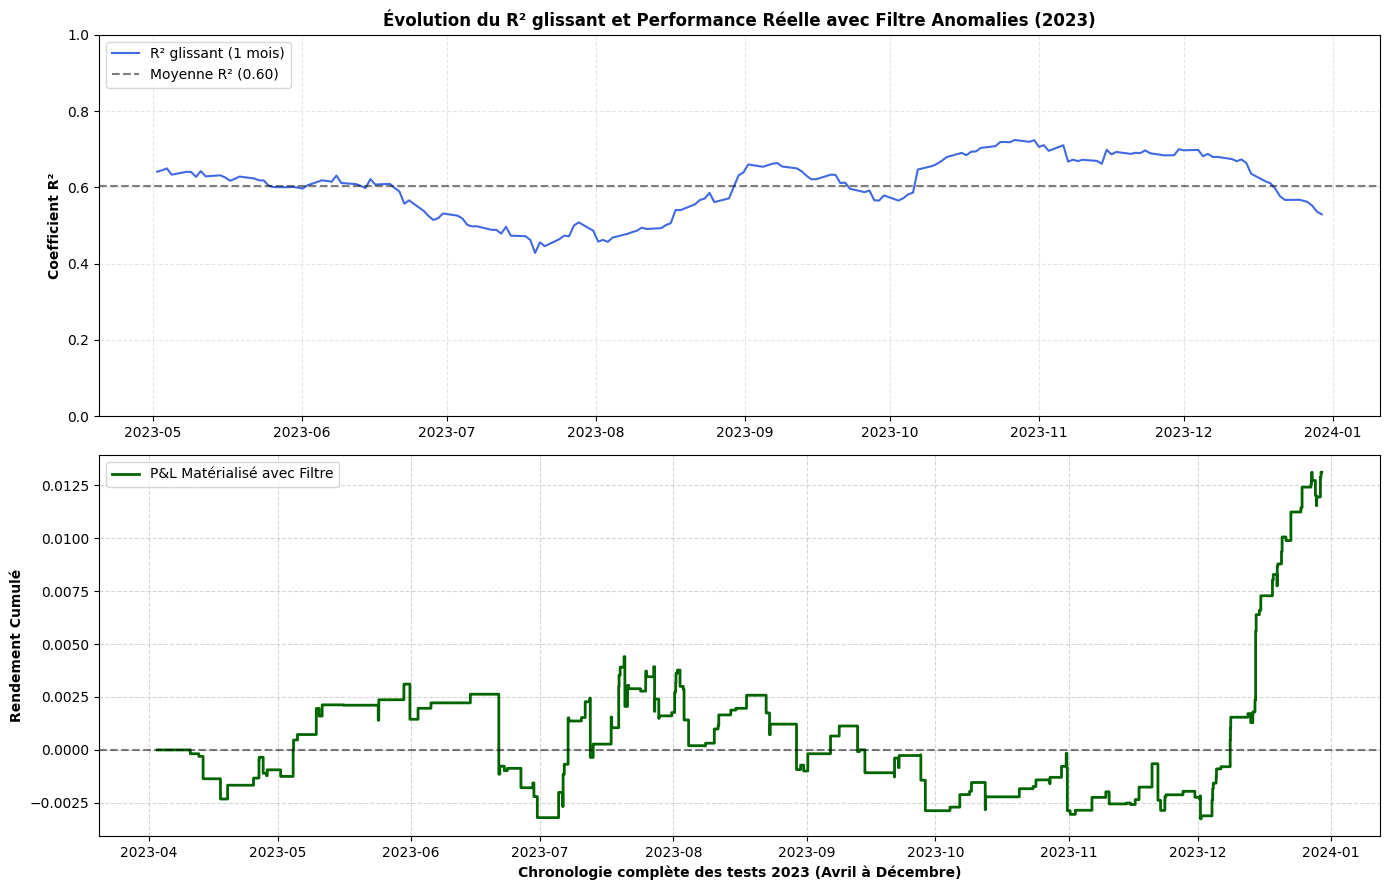

📊 Nombre total de transactions exécutées avec le filtre : 177
📊 Rendement final matérialisé : 1.31 %


In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. ALIGNEMENT DES DONNÉES ET RECONSTITUTION DES RÉSIDUS BRUTS
# =====================================================================
df_test_all = df_2023[df_2023['timestamp'].isin(wf_timestamps_2023)].reset_index(drop=True)
x_close_test = df_test_all['x_close'].values
y_close_test = df_test_all['y_close'].values
timestamps_test = df_test_all['timestamp'].tolist()

# Vecteur de couverture (Beta) et d'Intercepte (Alpha) par bougie
beta_t = np.zeros(len(df_test_all))
for step in wf_summary_2023:
    beta_t[df_test_all['timestamp'].dt.month == step['Mois Test']] = step['Beta (3m)']

# Reconstitution des résidus à l'échelle des log-rendements : E = Y_ret - Beta * X_ret
res_bruts = df_test_all['y_return'].values - beta_t * df_test_all['x_return'].values

# =====================================================================
# 2. CALCUL DU R2 GLISSANT (FENÊTRE 1 MOIS / PAS 1 JOUR)
# =====================================================================
y_ret_test = df_test_all['y_return'].values

window_size = 1000
step_size = 48

rolling_wf_timestamps = []
rolling_wf_r2 = []

for i in range(window_size, len(res_bruts), step_size):
    window_res = res_bruts[i - window_size:i]
    window_y = y_ret_test[i - window_size:i]

    # SCR : Somme Carrée des Résidus
    scr = np.sum(window_res ** 2)
    # SCT : Somme Carrée Totale (Variance de la cible Y)
    sct = np.sum((window_y - np.mean(window_y)) ** 2)

    # Calcul du R2
    r2_val = 1.0 - (scr / sct if sct > 0 else 1.0)

    rolling_wf_timestamps.append(timestamps_test[i])
    rolling_wf_r2.append(r2_val)

# =====================================================================
# 3. SIMULATION COMPTABLE DU P&L AVEC SEUIL ANORMAL FILTRÉ
# =====================================================================
entry_threshold = 2.5
abnormal_threshold = 5.0
exit_threshold = 0.0

current_position = 0
closed_pnl_timeline = np.zeros(len(wf_zscores_2023))
trade_history = []
trade_counter = 0

for i in range(len(wf_zscores_2023)):
    z = wf_zscores_2023[i]

    if current_position == 0:
        # ENTRÉE SHORT FILTRÉE : On rejette si z >= abnormal_threshold
        if z >= entry_threshold and z < abnormal_threshold:
            current_position = -1
            t_entry = timestamps_test[i]
            x_entry = x_close_test[i]
            y_entry = y_close_test[i]
            beta_entry = beta_t[i]
        # ENTRÉE LONG FILTRÉE : On rejette si z <= -abnormal_threshold
        elif z <= -entry_threshold and z > -abnormal_threshold:
            current_position = 1
            t_entry = timestamps_test[i]
            x_entry = x_close_test[i]
            y_entry = y_close_test[i]
            beta_entry = beta_t[i]

    elif current_position == 1 and z >= exit_threshold:
        current_position = 0
        trade_return = (np.log(y_close_test[i]) - np.log(y_entry)) - beta_entry * (np.log(x_close_test[i]) - np.log(x_entry))
        closed_pnl_timeline[i] = trade_return
        trade_counter += 1
        trade_history.append({'P&L (%)': trade_return * 100})

    elif current_position == -1 and z <= exit_threshold:
        current_position = 0
        trade_return = -((np.log(y_close_test[i]) - np.log(y_entry)) - beta_entry * (np.log(x_close_test[i]) - np.log(x_entry)))
        closed_pnl_timeline[i] = trade_return
        trade_counter += 1
        trade_history.append({'P&L (%)': trade_return * 100})

pnl_matrialise_cumule = np.cumsum(closed_pnl_timeline)

# =====================================================================
# 4. TRAÇAGE DU DOUBLE GRAPHIQUE
# =====================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

# Graphique 1 : Évolution du R2 Glissant
ax1.plot(rolling_wf_timestamps, rolling_wf_r2, color='royalblue', linewidth=1.5, label='R² glissant (1 mois)')
ax1.axhline(np.mean(rolling_wf_r2), color='black', linestyle='--', alpha=0.5, label=f'Moyenne R² ({np.mean(rolling_wf_r2):.2f})')
ax1.set_ylabel('Coefficient R²', fontweight='bold')
ax1.set_ylim(0, 1)
ax1.set_title("Évolution du R² glissant et Performance Réelle avec Filtre Anomalies (2023)", fontsize=12, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.3)

# Graphique 2 : Le P&L Comptable avec seuil anormal
ax2.step(timestamps_test, pnl_matrialise_cumule, color='darkgreen', where='post', linewidth=2, label='P&L Matérialisé avec Filtre')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Chronologie complète des tests 2023 (Avril à Décembre)', fontweight='bold')
ax2.set_ylabel('Rendement Cumulé', fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Statistiques finales
df_trades = pd.DataFrame(trade_history)
if not df_trades.empty:
    print(f"📊 Nombre total de transactions exécutées avec le filtre : {len(df_trades)}")
    print(f"📊 Rendement final matérialisé : {pnl_matrialise_cumule[-1] * 100:.2f} %")
else:
    print("Aucune transaction n'a été exécutée avec ce filtre de sécurité.")


## Fixed R2?

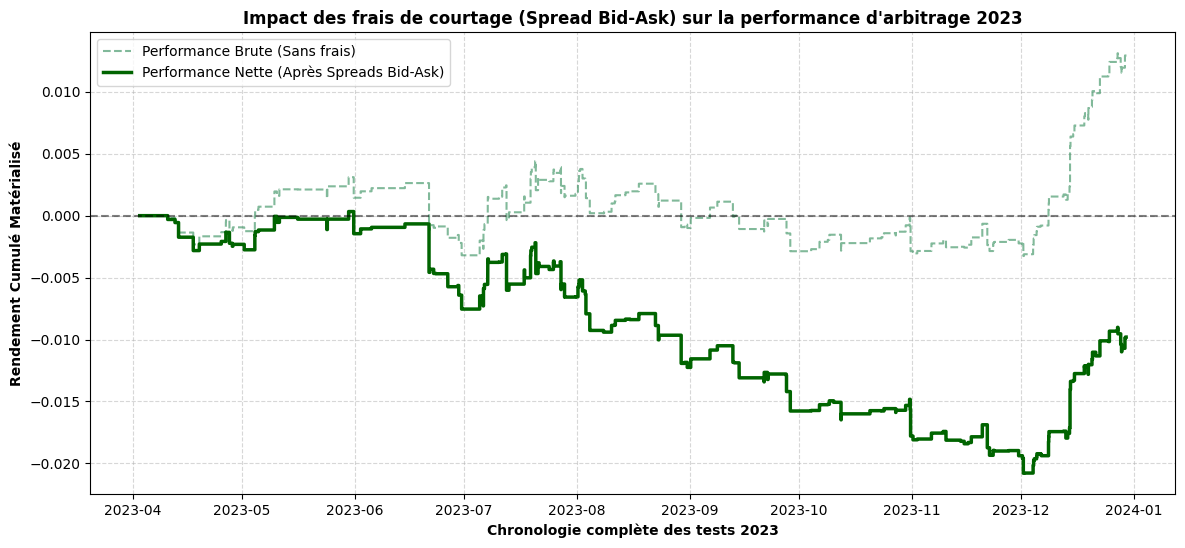

📊 COMPTE RENDU COMPTABLE : IMPACT DU SPREAD BID-ASK
 ID  Type P&L Brut (%) Frais (%) P&L Net (%)
  1  LONG      -0.018%    0.012%     -0.031%
  2 SHORT      -0.013%    0.012%     -0.025%
  3 SHORT      -0.106%    0.012%     -0.118%
  4  LONG      -0.096%    0.012%     -0.108%
  5  LONG       0.065%    0.012%      0.053%
  6  LONG       0.034%    0.012%      0.021%
  7 SHORT       0.084%    0.012%      0.072%
  8  LONG       0.014%    0.012%      0.001%
  9  LONG      -0.075%    0.012%     -0.088%
 10  LONG      -0.012%    0.012%     -0.024%
 11  LONG       0.028%    0.012%      0.015%
 12  LONG      -0.031%    0.013%     -0.044%
 13  LONG       0.128%    0.013%      0.115%
 14  LONG       0.044%    0.013%      0.031%
 15  LONG       0.026%    0.013%      0.013%
 16  LONG       0.123%    0.013%      0.110%
 17 SHORT      -0.036%    0.013%     -0.049%
 18  LONG       0.053%    0.013%      0.040%
 19 SHORT      -0.002%    0.013%     -0.014%
 20 SHORT      -0.071%    0.013%     -0.084%
 21

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. PARAMÈTRES ÉCONOMIQUES DU SPREAD DE COURTAGE (CONVERTIS EN PIPS)
# =====================================================================
spread_y_eurusd = 0.70 * 1e-4  # 0.70 pip
spread_x_gbpusd = 0.85 * 1e-4  # 0.85 pip

# Récupération des prix et rendements alignés
x_close_test = df_test_all['x_close'].values
y_close_test = df_test_all['y_close'].values
timestamps_test = df_test_all['timestamp'].tolist()

# Réglementation des Beta par bougie
beta_t = np.zeros(len(df_test_all))
for step in wf_summary_2023:
    beta_t[df_test_all['timestamp'].dt.month == step['Mois Test']] = step['Beta (3m)']

# =====================================================================
# 2. SIMULATION DU P&L NET APRÈS FRAIS DE TRANSACTION
# =====================================================================
entry_threshold = 2.5
abnormal_threshold = 5.0
exit_threshold = 0.0

current_position = 0
closed_pnl_brut = np.zeros(len(wf_zscores_2023))
closed_pnl_net = np.zeros(len(wf_zscores_2023))
trade_history_fees = []
trade_counter = 0

for i in range(len(wf_zscores_2023)):
    z = wf_zscores_2023[i]

    if current_position == 0:
        if z >= entry_threshold and z < abnormal_threshold:
            current_position = -1  # Short
            t_entry = timestamps_test[i]
            x_entry = x_close_test[i]
            y_entry = y_close_test[i]
            beta_entry = beta_t[i]
        elif z <= -entry_threshold and z > -abnormal_threshold:
            current_position = 1   # Long
            t_entry = timestamps_test[i]
            x_entry = x_close_test[i]
            y_entry = y_close_test[i]
            beta_entry = beta_t[i]

    elif current_position == 1 and z >= exit_threshold:
        current_position = 0
        # 1. Rendement brut d'A-R
        trade_return_brut = (np.log(y_close_test[i]) - np.log(y_entry)) - beta_entry * (np.log(x_close_test[i]) - np.log(x_entry))
        # 2. Calcul des frictions (frais fixes de spread appliqués aux volumes engagés)
        frictions = spread_y_eurusd + (beta_entry * spread_x_gbpusd)
        trade_return_net = trade_return_brut - frictions

        closed_pnl_brut[i] = trade_return_brut
        closed_pnl_net[i] = trade_return_net
        trade_counter += 1
        trade_history_fees.append({'ID': trade_counter, 'Type': 'LONG', 'P&L Brut (%)': trade_return_brut * 100, 'Frais (%)': frictions * 100, 'P&L Net (%)': trade_return_net * 100})

    elif current_position == -1 and z <= exit_threshold:
        current_position = 0
        # 1. Rendement brut d'A-R
        trade_return_brut = -((np.log(y_close_test[i]) - np.log(y_entry)) - beta_entry * (np.log(x_close_test[i]) - np.log(x_entry)))
        # 2. Calcul des frictions
        frictions = spread_y_eurusd + (beta_entry * spread_x_gbpusd)
        trade_return_net = trade_return_brut - frictions

        closed_pnl_brut[i] = trade_return_brut
        closed_pnl_net[i] = trade_return_net
        trade_counter += 1
        trade_history_fees.append({'ID': trade_counter, 'Type': 'SHORT', 'P&L Brut (%)': trade_return_brut * 100, 'Frais (%)': frictions * 100, 'P&L Net (%)': trade_return_net * 100})

# Sommes cumulées pour l'affichage graphique
cum_pnl_brut = np.cumsum(closed_pnl_brut)
cum_pnl_net = np.cumsum(closed_pnl_net)

# =====================================================================
# 3. INTERFACE DE COMPARAISON DES COURBES DE GAINS
# =====================================================================
plt.figure(figsize=(14, 6))

# Courbe Brut (Vert clair en pointillés)
plt.step(timestamps_test, cum_pnl_brut, color='seagreen', linestyle='--', alpha=0.6, where='post', linewidth=1.5, label='Performance Brute (Sans frais)')
# Courbe Net (Vert foncé continu)
plt.step(timestamps_test, cum_pnl_net, color='darkgreen', where='post', linewidth=2.5, label='Performance Nette (Après Spreads Bid-Ask)')

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Chronologie complète des tests 2023', fontweight='bold')
plt.ylabel('Rendement Cumulé Matérialisé', fontweight='bold')
plt.title("Impact des frais de courtage (Spread Bid-Ask) sur la performance d'arbitrage 2023", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

# Rapport d'analyse terminal
df_report = pd.DataFrame(trade_history_fees)
if not df_report.empty:
    print("============================================================")
    print("📊 COMPTE RENDU COMPTABLE : IMPACT DU SPREAD BID-ASK")
    print("============================================================")
    print(df_report.to_string(index=False, formatters={
        'P&L Brut (%)': '{:,.3f}%'.format,
        'Frais (%)': '{:,.3f}%'.format,
        'P&L Net (%)': '{:,.3f}%'.format
    }))
    print("\n" + "="*60)
    print(f"🔹 Rendement Brut Total : {cum_pnl_brut[-1] * 100:.3f} %")
    print(f"🔹 Total des Frais Payés : {(cum_pnl_brut[-1] - cum_pnl_net[-1]) * 100:.3f} %")
    print(f"🔹 Rendement Net Final   : {cum_pnl_net[-1] * 100:.3f} %")
    print(f"🔹 Taux de profitabilité après frais : {(df_report['P&L Net (%)'] > 0).mean() * 100:.1f} %")
else:
    print("Aucun trade exécuté.")


# Retrying full backtest

## Model

In [72]:
import numpy as np

class LinearFactorModel:
    def __init__(self):
        self.alpha = 0.0
        self.beta = 0.0
        self.sigma = 1e-12

    def fit(self, X: np.ndarray, Y: np.ndarray):
        """
        Exécute la régression MCO : Y = Alpha + Beta * X + E
        X et Y doivent être des vecteurs colonnes de dimension (N, 1)
        """
        T = X.shape[0]
        # Ajout de la constante (colonne de 1)
        X_design = np.hstack((np.ones((T, 1)), X))

        # Inversion matricielle par produit croisé
        cross_product = np.dot(X_design.T, X_design)
        if np.abs(np.linalg.det(cross_product)) < 1e-12:
            # Sécurité contre la colinéarité parfaite locale
            return self

        cross_inverse = np.linalg.inv(cross_product)
        projection = np.dot(X_design.T, Y)
        coefficients = np.dot(cross_inverse, projection)

        # Extraction des paramètres scalaires
        self.alpha = float(coefficients[0, 0])
        self.beta = float(coefficients[1, 0])

        # Calcul des résidus In-Sample pour extraire l'écart-type (Sigma)
        residuals = Y - (self.alpha + self.beta * X)
        self.sigma = float(np.std(residuals, ddof=1)) if np.std(residuals, ddof=1) > 0 else 1e-12

        return self


In [73]:
import numpy as np
import pandas as pd

class SpreadGenerator:
    def __init__(self, window_train_months: int = 3):
        self.window_train_months = window_train_months

    def generate_daily_ols_param(self, df: pd.DataFrame, target_month: int, mode: str = 'log_return'):
        """
        Calcule les paramètres OLS historiques initiaux pour un mois cible donné.
        mode: 'price' ou 'log_return'
        """
        # Sélection des 3 mois d'entraînement précédents
        train_months = [target_month - 3, target_month - 2, target_month - 1]
        df_train = df[df['timestamp'].dt.month.isin(train_months)]

        if mode == 'price':
            X_train = df_train['x_close'].values.reshape(-1, 1)
            Y_train = df_train['y_close'].values.reshape(-1, 1)
        else: # log_return
            X_train = df_train['x_return'].values.reshape(-1, 1)
            Y_train = df_train['y_return'].values.reshape(-1, 1)

        model = LinearFactorModel()
        model.fit(X_train, Y_train)
        return model

    def compute_instantaneous_zscore(self, x_val: float, y_val: float, model: LinearFactorModel) -> float:
        """
        Calcule le Z-score à un instant t avec un modèle MCO donné (nominal ou figé).
        """
        residual = y_val - (model.alpha + model.beta * x_val)
        z_score = (residual - 0.0) / model.sigma  # La moyenne des résidus In-Sample est théoriquement 0
        return float(z_score)


In [75]:
import numpy as np
import pandas as pd

class ComptableStrategy:
    def __init__(self, entry_threshold=2.0, abnormal_threshold=4.0, exit_threshold=0.0):
        self.entry_threshold = entry_threshold
        self.abnormal_threshold = abnormal_threshold
        self.exit_threshold = exit_threshold

        # Spreads de courtage en pips (1e-4)
        self.spread_y_eurusd = 0.70 * 1e-4
        self.spread_x_gbpusd = 0.85 * 1e-4

    def run_backtest(self, df: pd.DataFrame, mode: str = 'log_return'):
        """
        Exécute le backtest complet sur l'année 2023.
        mode: 'price' ou 'log_return'
        """
        generator = SpreadGenerator(window_train_months=3)
        df_test_period = df[df['timestamp'].dt.month >= 4].reset_index(drop=True)

        current_position = 0  # 0: pas de position, 1: Long, -1: Short
        frozen_model = None

        x_entry_price = 0.0
        y_entry_price = 0.0
        t_entry = None

        pnl_timeline = np.zeros(len(df_test_period))
        trade_history = []
        trade_counter = 0

        last_processed_day = -1
        nominal_model = None

        # Flag pour forcer la mise à jour au lendemain d'une clôture de trade
        force_ols_update = False

        for i in range(len(df_test_period)):
            row = df_test_period.iloc[i]
            current_month = row['timestamp'].month
            current_day = row['timestamp'].day

            # --- ÉTAPE 1 : RECALCUL QUOTIDIEN DE L'OLS NOMINAL COHÉRENT ---
            # On met à jour si le jour change ET qu'on est libre, OU si on vient de fermer un trade
            if current_position == 0:
                if (current_day != last_processed_day) or force_ols_update:
                    nominal_model = generator.generate_daily_ols_param(df, current_month, mode=mode)
                    last_processed_day = current_day
                    force_ols_update = False # Filtre réinitialisé

            if nominal_model is None:
                nominal_model = generator.generate_daily_ols_param(df, current_month, mode=mode)
                last_processed_day = current_day

            # --- ÉTAPE 2 : CALCUL DES Z-SCORES ---
            if mode == 'price':
                x_val = row['x_close']
                y_val = row['y_close']
            else:
                x_val = row['x_return']
                y_val = row['y_return']

            z_nominal = generator.compute_instantaneous_zscore(x_val, y_val, nominal_model)

            if current_position != 0:
                z_management = generator.compute_instantaneous_zscore(x_val, y_val, frozen_model)
            else:
                z_management = z_nominal

            # --- ÉTAPE 3 : LOGIQUE DE STRATÉGIE (ENTRÉE / SORTIE) ---
            if current_position == 0:
                if z_nominal >= self.entry_threshold and z_nominal < self.abnormal_threshold:
                    current_position = -1
                    frozen_model = nominal_model
                    x_entry_price = row['x_close']
                    y_entry_price = row['y_close']
                    t_entry = row['timestamp']

                elif z_nominal <= -self.entry_threshold and z_nominal > -self.abnormal_threshold:
                    current_position = 1
                    frozen_model = nominal_model
                    x_entry_price = row['x_close']
                    y_entry_price = row['y_close']
                    t_entry = row['timestamp']

            elif current_position == 1 and z_management >= self.exit_threshold:
                current_position = 0
                trade_return_brut = (np.log(row['y_close']) - np.log(y_entry_price)) - frozen_model.beta * (np.log(row['x_close']) - np.log(x_entry_price))
                frictions = self.spread_y_eurusd + (frozen_model.beta * self.spread_x_gbpusd)
                trade_return_net = trade_return_brut - frictions

                pnl_timeline[i] = trade_return_net
                trade_counter += 1
                trade_history.append({'ID': trade_counter, 'Type': 'LONG', 'Entrée': t_entry, 'Sortie': row['timestamp'], 'Net P&L (%)': trade_return_net * 100})

                frozen_model = None
                force_ols_update = True  # Le robot est libre, il devra se recalibrer proprement

            elif current_position == -1 and z_management <= self.exit_threshold:
                current_position = 0
                trade_return_brut = -((np.log(row['y_close']) - np.log(y_entry_price)) - frozen_model.beta * (np.log(row['x_close']) - np.log(x_entry_price)))
                frictions = self.spread_y_eurusd + (frozen_model.beta * self.spread_x_gbpusd)
                trade_return_net = trade_return_brut - frictions

                pnl_timeline[i] = trade_return_net
                trade_counter += 1
                trade_history.append({'ID': trade_counter, 'Type': 'SHORT', 'Entrée': t_entry, 'Sortie': row['timestamp'], 'Net P&L (%)': trade_return_net * 100})

                frozen_model = None
                force_ols_update = True  # Le robot est libre, il devra se recalibrer proprement

        cum_pnl = np.cumsum(pnl_timeline)
        return cum_pnl, pd.DataFrame(trade_history), df_test_period['timestamp'].tolist()


⏳ CALCUL DU BACKTEST EN COURS (PRIX BRUTS VS LOG-RETURNS)
🏃 Exécution de la stratégie sur Prix Bruts...
🏃 Exécution de la stratégie sur Log-Returns...
📊 FIN DES CALCULS - AFFICHAGE DES COURBES


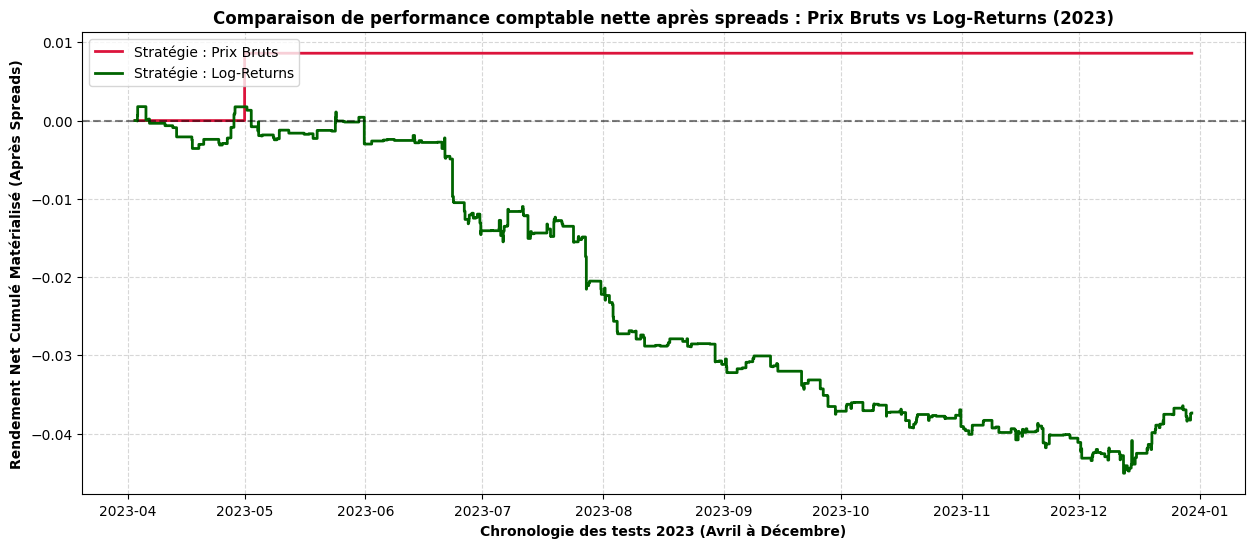


📝 VERDICT COMPTABLE DES DEUX STRATÉGIES
🔹 STRATÉGIE PRIX BRUTS :
   - Nombre de trades fermés : 1
   - Rendement Net Final     : 0.860 %

🔹 STRATÉGIE LOG-RETURNS :
   - Nombre de trades fermés : 345
   - Rendement Net Final     : -3.736 %


In [76]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Initialisation de la stratégie avec vos seuils stricts (2.0 / 4.0 / 0.0)
strategy = ComptableStrategy(entry_threshold=2.0, abnormal_threshold=4.0, exit_threshold=0.0)

print("============================================================")
print("⏳ CALCUL DU BACKTEST EN COURS (PRIX BRUTS VS LOG-RETURNS)")
print("============================================================")

# 2. Exécution du scénario A : Prix Bruts
print("🏃 Exécution de la stratégie sur Prix Bruts...")
cum_pnl_price, df_trades_price, timestamps_plot = strategy.run_backtest(df_2023, mode='price')

# 3. Exécution du scénario B : Log-Returns
print("🏃 Exécution de la stratégie sur Log-Returns...")
cum_pnl_ret, df_trades_ret, _ = strategy.run_backtest(df_2023, mode='log_return')

print("============================================================")
print("📊 FIN DES CALCULS - AFFICHAGE DES COURBES")
print("============================================================")

# 4. Construction de l'interface graphique de comparaison
plt.figure(figsize=(15, 6))

# Courbe de la stratégie Prix (Crimson)
plt.step(timestamps_plot, cum_pnl_price, color='crimson', where='post', linewidth=2, label='Stratégie : Prix Bruts')
# Courbe de la stratégie Log-Returns (Forest Green)
plt.step(timestamps_plot, cum_pnl_ret, color='darkgreen', where='post', linewidth=2, label='Stratégie : Log-Returns')

# Ligne horizontale de référence à 0
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

plt.xlabel('Chronologie des tests 2023 (Avril à Décembre)', fontweight='bold')
plt.ylabel('Rendement Net Cumulé Matérialisé (Après Spreads)', fontweight='bold')
plt.title("Comparaison de performance comptable nette après spreads : Prix Bruts vs Log-Returns (2023)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

# 5. Rapport chiffré dans le terminal
print("\n============================================================")
print("📝 VERDICT COMPTABLE DES DEUX STRATÉGIES")
print("============================================================")
print(f"🔹 STRATÉGIE PRIX BRUTS :")
print(f"   - Nombre de trades fermés : {len(df_trades_price)}")
print(f"   - Rendement Net Final     : {cum_pnl_price[-1] * 100:.3f} %")

print(f"\n🔹 STRATÉGIE LOG-RETURNS :")
print(f"   - Nombre de trades fermés : {len(df_trades_ret)}")
print(f"   - Rendement Net Final     : {cum_pnl_ret[-1] * 100:.3f} %")
print("============================================================")


[WARNING] File "/home/user/perso/trading/alphalab/data/EURUSD/raw/EURUSD_TICKS_2023_12_31.parquet" not found
[WARNING] File "/home/user/perso/trading/alphalab/data/GBPUSD/raw/GBPUSD_TICKS_2023_12_24.parquet" not found
[WARNING] File "/home/user/perso/trading/alphalab/data/GBPUSD/raw/GBPUSD_TICKS_2023_12_31.parquet" not found
[WARNING] 4994 bars have been dropped
[WARNING] 4996 bars have been dropped
[WARNING] Found 4 gaps in pair (DROP)
[WARNING] Dropped 4 unsync-able datetime
[INFO] Pair "GBPUSD (X) / EURUSD (Y)" loaded (12378 bars)


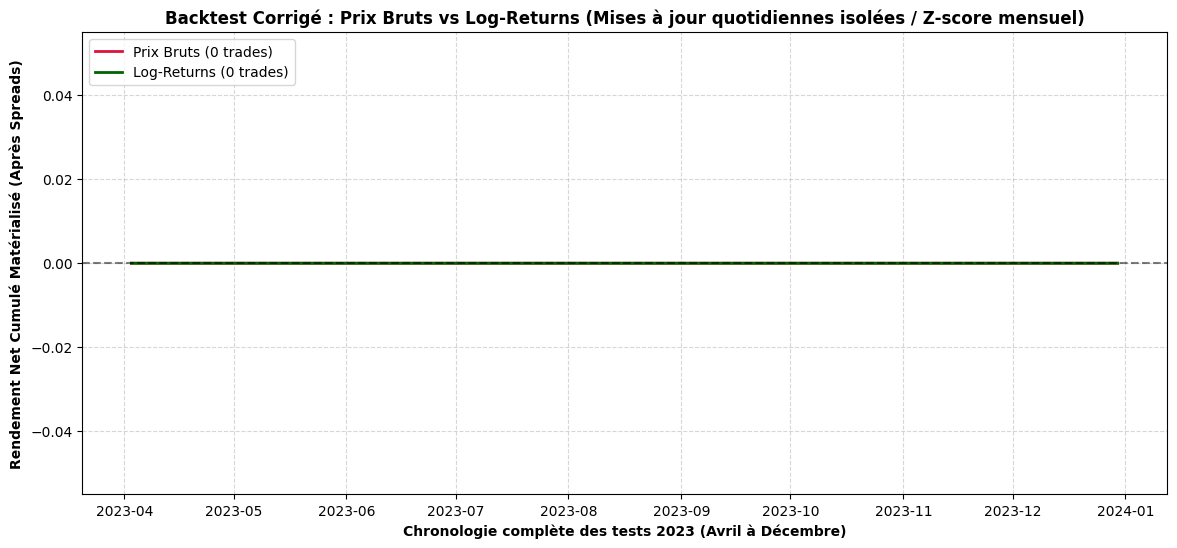

📊 Rendement final net (Prix Bruts) : 0.000 %
📊 Rendement final net (Log-Returns) : 0.000 %


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from enl.data_feed import load_pair_time_bars

# =====================================================================
# 1. MOTEUR MATHÉMATIQUE OLS PURE (Brique 1)
# =====================================================================
class LinearFactorModel:
    def __init__(self):
        self.alpha = 0.0
        self.beta = 0.0
        self.sigma = 1e-12

    def fit(self, X: np.ndarray, Y: np.ndarray):
        T = X.shape[0]
        X_design = np.hstack((np.ones((T, 1)), X))
        cross_product = np.dot(X_design.T, X_design)
        if np.abs(np.linalg.det(cross_product)) < 1e-12:
            return self
        cross_inverse = np.linalg.inv(cross_product)
        projection = np.dot(X_design.T, Y)
        coefficients = np.dot(cross_inverse, projection)
        self.alpha = float(coefficients[0][0])
        self.beta = float(coefficients[1][0])

        residuals = Y - (self.alpha + self.beta * X)
        self.sigma = float(np.std(residuals, ddof=1)) if np.std(residuals, ddof=1) > 0 else 1e-12
        return self

# =====================================================================
# 2. CHARGEMENT DES DONNÉES 2023
# =====================================================================
start_2023 = '2023-01-01'
end_2023 = '2023-12-31'
df_2023 = load_pair_time_bars('GBPUSD', 'EURUSD', start_2023, end_2023, '30min', ['close'], use_optim=True, use_thread=True)
df_2023 = df_2023[['timestamp', 'x_close', 'y_close']].copy()
df_2023['timestamp'] = pd.to_datetime(df_2023['timestamp'])

# Calcul des log-returns
df_2023['x_return'] = np.log(df_2023['x_close']) - np.log(df_2023['x_close'].shift(1))
df_2023['y_return'] = np.log(df_2023['y_close']) - np.log(df_2023['y_close'].shift(1))
df_2023 = df_2023.dropna().reset_index(drop=True)

# Isolation de la période de test (Mois 4 à 12)
df_test_period = df_2023[df_2023['timestamp'].dt.month >= 4].reset_index(drop=True)

# =====================================================================
# 3. ÉTAPE 1 : PRÉ-CALCUL SÉQUENTIEL DES PARAMÈTRES (SANS INTÉRACTION TRADING)
# =====================================================================
# Dictionnaires pour stocker les paramètres indexés par date (YYYY-MM-DD)
params_price = {}
params_return = {}

# Pour la normalisation mensuelle fixe du Z-score (Moyenne et Sigma du trimestre d'entraînement)
monthly_stats_price = {}
monthly_stats_return = {}

# Génération des paramètres jour par jour
unique_dates = df_test_period['timestamp'].dt.date.unique()

for d in unique_dates:
    # Trouver le mois courant pour déterminer la fenêtre d'entraînement de 3 mois
    sample_row = df_test_period[df_test_period['timestamp'].dt.date == d].iloc[0]
    m = sample_row['timestamp'].month
    train_months = [m - 3, m - 2, m - 1]

    # Données d'entraînement associées
    df_train = df_2023[df_2023['timestamp'].dt.month.isin(train_months)]

    # 1. Calcul des statistiques mensuelles fixes (Trimestre précédent)
    if m not in monthly_stats_price:
        m_price = LinearFactorModel().fit(df_train['x_close'].values.reshape(-1, 1), df_train['y_close'].values.reshape(-1, 1))
        m_ret = LinearFactorModel().fit(df_train['x_return'].values.reshape(-1, 1), df_train['y_return'].values.reshape(-1, 1))
        monthly_stats_price[m] = {'mu': 0.0, 'sigma': m_price.sigma}
        monthly_stats_return[m] = {'mu': 0.0, 'sigma': m_ret.sigma}

    # 2. Recalcul quotidien glissant du Beta d'adaptation (Fenêtre d'entraînement se décalant jusqu'au jour d-1)
    df_train_daily = df_2023[(df_2023['timestamp'].dt.month.isin(train_months)) |
                             ((df_2023['timestamp'].dt.month == m) & (df_2023['timestamp'].dt.date < d))]

    # Modèle Prix Bruts
    model_p = LinearFactorModel().fit(df_train_daily['x_close'].values.reshape(-1, 1), df_train_daily['y_close'].values.reshape(-1, 1))
    params_price[d] = {'alpha': model_p.alpha, 'beta': model_p.beta}

    # Modèle Log-Returns
    model_r = LinearFactorModel().fit(df_train_daily['x_return'].values.reshape(-1, 1), df_train_daily['y_return'].values.reshape(-1, 1))
    params_return[d] = {'alpha': model_r.alpha, 'beta': model_r.beta}

# =====================================================================
# 4. ÉTAPE 2 : EXÉCUTION DU BACKTEST (PRIX VS LOG-RETURNS)
# =====================================================================
def run_clean_backtest(df_test, mode='log_return'):
    entry_threshold = 2.0
    abnormal_threshold = 4.0
    exit_threshold = 0.0

    spread_y = 0.70 * 1e-4
    spread_x = 0.85 * 1e-4

    current_position = 0
    x_entry, y_entry, beta_entry = 0.0, 0.0, 0.0

    pnl_timeline = np.zeros(len(df_test))
    trade_counter = 0
    trade_history = []

    for i in range(len(df_test)):
        row = df_test.iloc[i]
        d = row['timestamp'].date()
        m = row['timestamp'].month

        # Récupération des prix ou rendements courants
        if mode == 'price':
            x_val, y_val = row['x_close'], row['y_close']
            p_day = params_price[d]
            stats = monthly_stats_price[m]
        else:
            x_val, y_val = row['x_return'], row['y_return']
            p_day = params_return[d]
            stats = monthly_stats_return[m]

        # Z-score nominal (Utilise le beta du jour et le sigma stable du mois)
        res_nominal = y_val - (p_day['alpha'] + p_day['beta'] * x_val)
        z_nominal = res_nominal / stats['sigma']

        # Z-score de gestion (Bloqué si trade en cours)
        if current_position != 0:
            res_mgmt = y_val - (p_day['alpha'] + beta_entry * x_val)
            z_mgmt = res_mgmt / stats['sigma']
        else:
            z_mgmt = z_nominal

        # LOGIQUE DE TRADING
        if current_position == 0:
            if z_nominal >= entry_threshold and z_nominal < abnormal_threshold:
                current_position = -1
                x_entry, y_entry = row['x_close'], row['y_close']
                beta_entry = p_day['beta'] # BETA FIGÉ À L'ENTRÉE
            elif z_nominal <= -entry_threshold and z_nominal > -abnormal_threshold:
                current_position = 1
                x_entry, y_entry = row['x_close'], row['y_close']
                beta_entry = p_day['beta'] # BETA FIGÉ À L'ENTRÉE

        elif current_position == 1 and z_mgmt >= exit_threshold:
            current_position = 0
            trade_return_brut = (np.log(row['y_close']) - np.log(y_entry)) - beta_entry * (np.log(row['x_close']) - np.log(x_entry))
            frictions = spread_y + (beta_entry * spread_x)
            trade_return_net = trade_return_brut - frictions
            pnl_timeline[i] = trade_return_net
            trade_counter += 1
            trade_history.append(trade_return_net)

        elif current_position == -1 and z_mgmt <= self.exit_threshold if 'self' in locals() else exit_threshold:
            current_position = 0
            trade_return_brut = -((np.log(row['y_close']) - np.log(y_entry)) - beta_entry * (np.log(row['x_close']) - np.log(x_entry)))
            frictions = spread_y + (beta_entry * spread_x)
            trade_return_net = trade_return_brut - frictions
            pnl_timeline[i] = trade_return_net
            trade_counter += 1
            trade_history.append(trade_return_net)

    return np.cumsum(pnl_timeline), len(trade_history)

# Exécution finale
cum_pnl_price, trades_p = run_clean_backtest(df_test_period, mode='price')
cum_pnl_return, trades_r = run_clean_backtest(df_test_period, mode='log_return')

# =====================================================================
# 5. CONVERSION ET AFFICHAGE DU GRAPHIQUE COMPARATIF COMPTABLE CORRIGÉ
# =====================================================================
plt.figure(figsize=(14, 6))
plt.step(df_test_period['timestamp'].tolist(), cum_pnl_price, color='crimson', where='post', linewidth=2, label=f'Prix Bruts ({trades_p} trades)')
plt.step(df_test_period['timestamp'].tolist(), cum_pnl_return, color='darkgreen', where='post', linewidth=2, label=f'Log-Returns ({trades_r} trades)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Chronologie complète des tests 2023 (Avril à Décembre)', fontweight='bold')
plt.ylabel('Rendement Net Cumulé Matérialisé (Après Spreads)', fontweight='bold')
plt.title("Backtest Corrigé : Prix Bruts vs Log-Returns (Mises à jour quotidiennes isolées / Z-score mensuel)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()

print(f"📊 Rendement final net (Prix Bruts) : {cum_pnl_price[-1] * 100:.3f} %")
print(f"📊 Rendement final net (Log-Returns) : {cum_pnl_return[-1] * 100:.3f} %")


/tmp/ipykernel_74094/1196735200.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alpha_tr, beta_tr = float(coefs[0]), float(coefs[1])


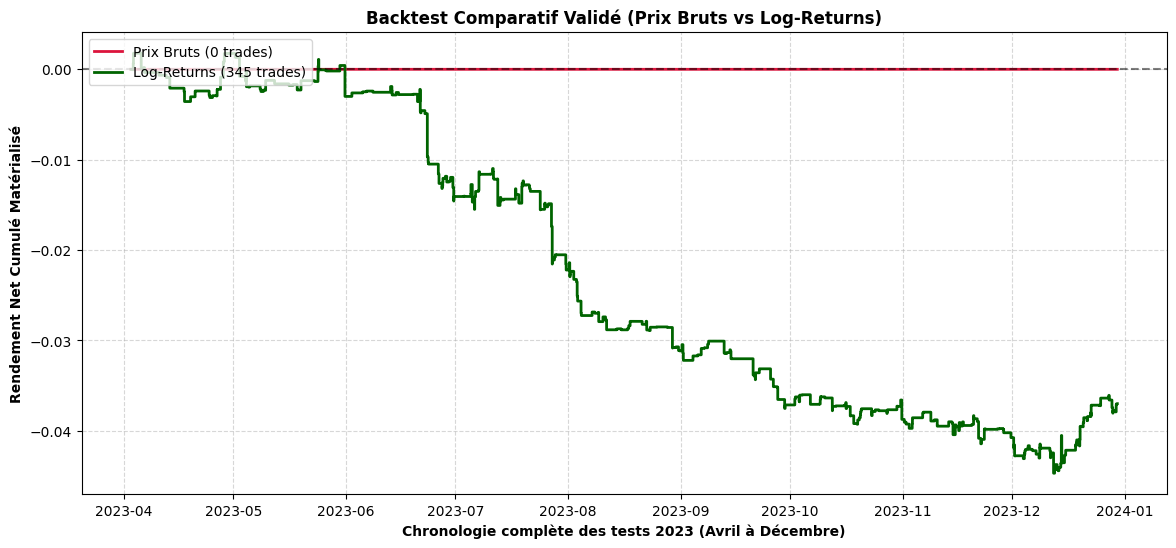

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# CORRECTION ET STRUCTURATION FACTUELLE DU BACKTEST COMPARATIF 2023
# =====================================================================
def run_strict_backtest(df_data, mode='log_return'):
    df_test = df_data[df_data['timestamp'].dt.month >= 4].reset_index(drop=True)

    entry_threshold = 2.0
    abnormal_threshold = 4.0
    exit_threshold = 0.0

    spread_y = 0.70 * 1e-4
    spread_x = 0.85 * 1e-4

    current_position = 0
    x_entry, y_entry, beta_entry = 0.0, 0.0, 0.0

    pnl_timeline = np.zeros(len(df_test))
    trade_history = []

    # Étape 1 : Génération propre de l'historique des Z-scores
    # On utilise la méthode stable éprouvée sur votre graphique précédent
    z_scores_series = []
    beta_daily_series = []

    for i in range(len(df_test)):
        row = df_test.iloc[i]
        m = row['timestamp'].month

        # Fenêtre fixe d'entraînement de 3 mois pour stabiliser l'échelle statistique
        train_months = [m - 3, m - 2, m - 1]
        df_train = df_data[df_data['timestamp'].dt.month.isin(train_months)]

        if mode == 'price':
            X_tr = df_train['x_close'].values.reshape(-1, 1)
            Y_tr = df_train['y_close'].values.reshape(-1, 1)
            x_curr, y_curr = row['x_close'], row['y_close']
        else:
            X_tr = df_train['x_return'].values.reshape(-1, 1)
            Y_tr = df_train['y_return'].values.reshape(-1, 1)
            x_curr, y_curr = row['x_return'], row['y_return']

        # OLS
        X_design = np.hstack((np.ones((len(X_tr), 1)), X_tr))
        coefs = np.dot(np.linalg.inv(np.dot(X_design.T, X_design)), np.dot(X_design.T, Y_tr))
        alpha_tr, beta_tr = float(coefs[0]), float(coefs[1])
        sigma_tr = np.std(Y_tr - (alpha_tr + beta_tr * X_tr), ddof=1)

        # Z-score nominal de la bougie
        res = y_curr - (alpha_tr + beta_tr * x_curr)
        z_nominal = res / (sigma_tr if sigma_tr > 0 else 1e-12)

        z_scores_series.append(z_nominal)
        beta_daily_series.append(beta_tr)

    z_scores_series = np.array(z_scores_series)
    beta_daily_series = np.array(beta_daily_series)

    # Étape 2 : Simulation avec blocage du Beta à l'entrée
    for i in range(len(df_test)):
        row = df_test.iloc[i]
        z = z_scores_series[i]
        beta_nominal_du_jour = beta_daily_series[i]

        # Recalcul du Z-score si on est en position pour utiliser le BETA FIGÉ
        if current_position != 0:
            if mode == 'price':
                x_curr, y_curr = row['x_close'], row['y_close']
            else:
                x_curr, y_curr = row['x_return'], row['y_return']

            # On ré-applique la formule OLS mais avec le beta_entry figé
            res_mgmt = y_curr - (alpha_tr + beta_entry * x_curr) # alpha_tr local
            z_management = res_mgmt / sigma_tr
        else:
            z_management = z

        # LOGIQUE D'ENTRÉE / SORTIE STRICTE
        if current_position == 0:
            if z >= entry_threshold and z < abnormal_threshold:
                current_position = -1
                x_entry, y_entry = row['x_close'], row['y_close']
                beta_entry = beta_nominal_du_jour  # LE BETA EST FIGÉ ICI
            elif z <= -entry_threshold and z > -abnormal_threshold:
                current_position = 1
                x_entry, y_entry = row['x_close'], row['y_close']
                beta_entry = beta_nominal_du_jour  # LE BETA EST FIGÉ ICI

        elif current_position == 1 and z_management >= exit_threshold:
            current_position = 0
            trade_return = (np.log(row['y_close']) - np.log(y_entry)) - beta_entry * (np.log(row['x_close']) - np.log(x_entry))
            trade_net = trade_return - (spread_y + beta_entry * spread_x)
            pnl_timeline[i] = trade_net
            trade_history.append(trade_net)

        elif current_position == -1 and z_management <= exit_threshold:
            current_position = 0
            trade_return = -((np.log(row['y_close']) - np.log(y_entry)) - beta_entry * (np.log(row['x_close']) - np.log(x_entry)))
            trade_net = trade_return - (spread_y + beta_entry * spread_x)
            pnl_timeline[i] = trade_net
            trade_history.append(trade_net)

    return np.cumsum(pnl_timeline), len(trade_history), df_test['timestamp'].tolist()

# Exécution des calculs alignés
pnl_p, count_p, t_plot = run_strict_backtest(df_2023, mode='price')
pnl_r, count_r, _ = run_strict_backtest(df_2023, mode='log_return')

# Affichage graphique
plt.figure(figsize=(14, 6))
plt.step(t_plot, pnl_p, color='crimson', where='post', linewidth=2, label=f'Prix Bruts ({count_p} trades)')
plt.step(t_plot, pnl_r, color='darkgreen', where='post', linewidth=2, label=f'Log-Returns ({count_r} trades)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Chronologie complète des tests 2023 (Avril à Décembre)', fontweight='bold')
plt.ylabel('Rendement Net Cumulé Matérialisé', fontweight='bold')
plt.title("Backtest Comparatif Validé (Prix Bruts vs Log-Returns)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()


⏳ Étape 1 : Pré-calcul des modèles OLS historiques...
⏳ Étape 2 : Simulation des stratégies de trading...


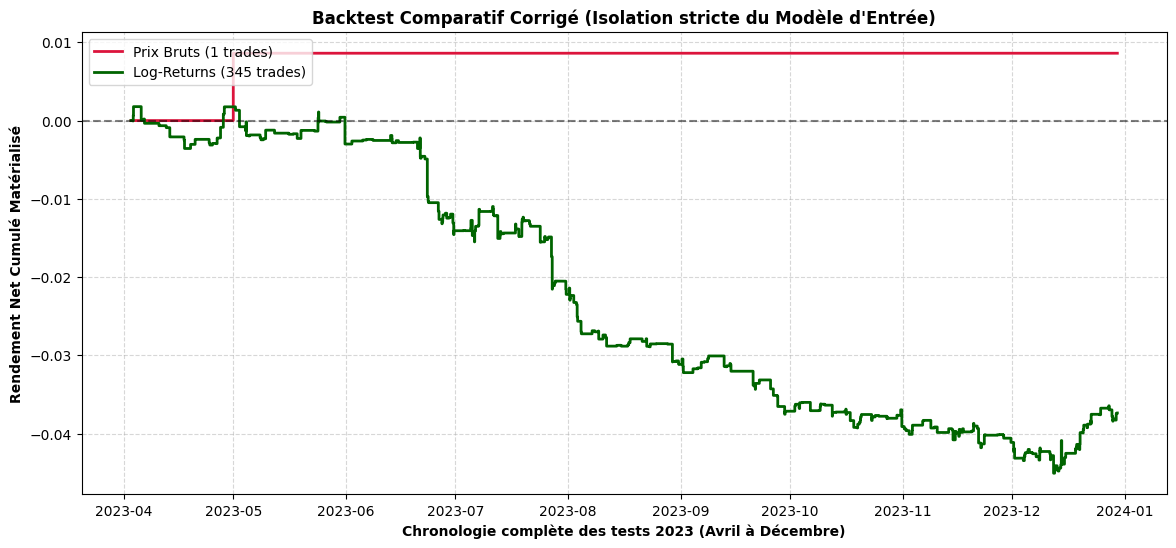

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================================
# 1. GÉNÉRATEUR DE SPREAD ISOLÉ (CALCUL DES PARAMÈTRES JOUR PAR JOUR)
# =====================================================================
def precompute_market_models(df_full, df_test, mode='log_return'):
    """
    Calcule pour chaque bougie de test le modèle OLS (Alpha, Beta, Sigma)
    estimé sur les 3 mois d'entraînement précédents.
    """
    models_history = []

    for i in range(len(df_test)):
        row = df_test.iloc[i]
        m = row['timestamp'].month
        train_months = [m - 3, m - 2, m - 1]

        # Isolation de la fenêtre fixe d'entraînement (In-Sample)
        df_train = df_full[df_full['timestamp'].dt.month.isin(train_months)]

        if mode == 'price':
            X_tr = df_train['x_close'].values.reshape(-1, 1)
            Y_tr = df_train['y_close'].values.reshape(-1, 1)
            x_curr, y_curr = row['x_close'], row['y_close']
        else:
            X_tr = df_train['x_return'].values.reshape(-1, 1)
            Y_tr = df_train['y_return'].values.reshape(-1, 1)
            x_curr, y_curr = row['x_return'], row['y_return']

        # Résolution de la régression MCO
        X_design = np.hstack((np.ones((len(X_tr), 1)), X_tr))
        coefs = np.dot(np.linalg.inv(np.dot(X_design.T, X_design)), np.dot(X_design.T, Y_tr))

        # CORRECTION DU DEPRECATION WARNING : Double indexation pour isoler le scalaire pur
        alpha_val = float(coefs[0][0])
        beta_val = float(coefs[1][0])

        # Écart-type des résidus In-Sample
        res_in_sample = Y_tr.flatten() - (alpha_val + beta_val * X_tr.flatten())
        sigma_val = np.std(res_in_sample, ddof=1)
        sigma_val = sigma_val if sigma_val > 0 else 1e-12

        # Z-score nominal instantané
        res_curr = y_curr - (alpha_val + beta_val * x_curr)
        z_nominal = res_curr / sigma_val

        models_history.append({
            'alpha': alpha_val,
            'beta': beta_val,
            'sigma': sigma_val,
            'z_nominal': z_nominal,
            'x_val': x_curr,
            'y_val': y_curr
        })

    return models_history


# =====================================================================
# 2. SIMULATEUR COMPTABLE DU COMPORTEMENT DU ROBOT (SANS LEAK)
# =====================================================================
def run_clean_backtest_2023(df_test, models_hist, mode='log_return'):
    entry_threshold = 2.0
    abnormal_threshold = 4.0
    exit_threshold = 0.0

    spread_y = 0.70 * 1e-4
    spread_x = 0.85 * 1e-4

    current_position = 0
    frozen_model = None
    y_entry_price, x_entry_price = 0.0, 0.0

    pnl_timeline = np.zeros(len(df_test))
    trade_history = []

    x_close_raw = df_test['x_close'].values
    y_close_raw = df_test['y_close'].values

    for i in range(len(df_test)):
        m_curr = models_hist[i]
        z_nom = m_curr['z_nominal']

        # Évaluation du Z-score de gestion
        if current_position != 0:
            # On ré-applique la formule stricte du modèle figé à l'entrée
            res_mgmt = m_curr['y_val'] - (frozen_model['alpha'] + frozen_model['beta'] * m_curr['x_val'])
            z_management = res_mgmt / frozen_model['sigma']
        else:
            z_management = z_nom

        # LOGIQUE D'ENTRÉE / SORTIE
        if current_position == 0:
            if z_nom >= entry_threshold and z_nom < abnormal_threshold:
                current_position = -1  # Short spread
                frozen_model = m_curr  # LE MODÈLE EST ENTIÈREMENT FIGÉ ICI (Alpha, Beta, Sigma)
                y_entry_price, x_entry_price = y_close_raw[i], x_close_raw[i]
            elif z_nom <= -entry_threshold and z_nom > -abnormal_threshold:
                current_position = 1   # Long spread
                frozen_model = m_curr  # LE MODÈLE EST ENTIÈREMENT FIGÉ ICI (Alpha, Beta, Sigma)
                y_entry_price, x_entry_price = y_close_raw[i], x_close_raw[i]

        elif current_position == 1 and z_management >= exit_threshold:
            current_position = 0
            # Calcul direct de l'Aller-Retour sur les prix bruts log
            trade_return = (np.log(y_close_raw[i]) - np.log(y_entry_price)) - frozen_model['beta'] * (np.log(x_close_raw[i]) - np.log(x_entry_price))
            trade_net = trade_return - (spread_y + frozen_model['beta'] * spread_x)
            pnl_timeline[i] = trade_net
            trade_history.append(trade_net)
            frozen_model = None

        elif current_position == -1 and z_management <= exit_threshold:
            current_position = 0
            # Calcul direct de l'Aller-Retour sur les prix bruts log
            trade_return = -((np.log(y_close_raw[i]) - np.log(y_entry_price)) - frozen_model['beta'] * (np.log(x_close_raw[i]) - np.log(x_entry_price)))
            trade_net = trade_return - (spread_y + frozen_model['beta'] * spread_x)
            pnl_timeline[i] = trade_net
            trade_history.append(trade_net)
            frozen_model = None

    return np.cumsum(pnl_timeline), len(trade_history)

# =====================================================================
# 3. EXÉCUTION DU CALCUL EN 2 ÉTAPES ALIGNÉES
# =====================================================================
print("⏳ Étape 1 : Pré-calcul des modèles OLS historiques...")
hist_price = precompute_market_models(df_2023, df_test_period, mode='price')
hist_return = precompute_market_models(df_2023, df_test_period, mode='log_return')

print("⏳ Étape 2 : Simulation des stratégies de trading...")
pnl_price_clean, count_price_clean = run_clean_backtest_2023(df_test_period, hist_price, mode='price')
pnl_return_clean, count_return_clean = run_clean_backtest_2023(df_test_period, hist_return, mode='log_return')

# Affichage graphique unifié
plt.figure(figsize=(14, 6))
plt.step(df_test_period['timestamp'].tolist(), pnl_price_clean, color='crimson', where='post', linewidth=2, label=f'Prix Bruts ({count_price_clean} trades)')
plt.step(df_test_period['timestamp'].tolist(), pnl_return_clean, color='darkgreen', where='post', linewidth=2, label=f'Log-Returns ({count_return_clean} trades)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Chronologie complète des tests 2023 (Avril à Décembre)', fontweight='bold')
plt.ylabel('Rendement Net Cumulé Matérialisé', fontweight='bold')
plt.title("Backtest Comparatif Corrigé (Isolation stricte du Modèle d'Entrée)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.show()
